# STOP ALGO TRADING MODEL

## Introduction — From the general STOP framework to forecasting policy search

The general STOP framework introduced a question that changes how we think about artificial intelligence: can a system improve the procedure through which it improves solutions? In the earlier teaching material, the central object was an improver, a program that organizes proposals, evaluates alternatives, and selects stronger candidates. The language model supplied ideas, but an external evaluation decided whether those ideas worked. This notebook brings that architecture into an algorithmic trading research setting. Our immediate task is to forecast tomorrow's return of a synthetic stock index. Our deeper task is to investigate whether better search procedures discover better forecasting policies.

Recall the distinction between an answer and the machinery that produces answers. Asking a language model for a forecast produces an answer. Asking it for several forecasting policies, testing those policies, and retaining the strongest creates an improvement process. Asking it to propose changes to that process introduces the second level of optimization associated with STOP. The teaching note describes this as improving the scaffold surrounding a fixed model. Here, the scaffold determines how many policies to propose, how many search rounds to run, how many promising policies to retain, and what strategic instructions guide the next set of proposals.

A useful analogy is an investment research laboratory. The forecasting models are analysts with different specialties. Some rely on historical averages, some emphasize recent movements, and others learn relationships among market indicators. A forecasting policy is the research director's rule for combining those analysts. The inner improver searches for a better combination. The outer optimizer evaluates alternative ways of organizing that search. Changing the research procedure does not change the language model's neural weights. It changes how the larger system uses its capabilities. Keeping these roles separate is the first step toward understanding every subsequent cell in this notebook.

The market environment is synthetic. We generate several index histories with changing conditions: relatively calm upward markets, volatile declines, sideways behavior, and recoveries. Random seeds create reproducible histories with different sequences of events. This lets us compare candidates under controlled conditions without requiring a market data subscription. It also limits what the experiment establishes. Success means performance within this designed environment, rather than evidence of profitability in an actual exchange. The synthetic setting is a teaching laboratory in which uncertainty, changing regimes, and imperfect information are present, while the underlying construction remains available for inspection and explanation by students.

The system begins with twenty forecasting models drawn from statistics, econometrics, and machine learning. Each produces a forecast of the next daily log return. The models themselves are implemented in ordinary Python libraries. The language model does not calculate their predictions or invent executable forecasting programs during the search. Instead, it proposes compact specifications describing which existing models to combine and what weights to assign. A policy contains different combinations for observable market conditions. Those conditions are estimated from recent momentum and volatility; the true hidden regime is reserved for later diagnostics. This separation prevents the policy from receiving privileged information.

We then need a consistent definition of improvement. This implementation compares a candidate's forecast error with the error of a naive forecast that predicts zero return. A utility above one indicates lower error than that benchmark; a value below one indicates higher error. The score is capped for stability. Policies are evaluated across validation periods from several training markets, and their average utility determines selection. Thus, persuasive language cannot make a candidate win. It must generate predictions that score better under the fixed rule. Directional accuracy is also reported, but it is not the objective driving the current selection process.

The inner loop starts from a simple initial policy. Under a specified search recipe, it requests alternative policies, evaluates them, retains the strongest candidates, and optionally repeats. The outer loop changes the recipe itself. To evaluate an improver specification, the program runs its inner search and measures the quality of the policy it discovers. That is the crucial link to meta-utility in the general framework: we judge a method by the downstream results it produces. The generations labeled I0, I1, and I2 therefore represent successive selected search specifications, together with the policies obtained by running those specifications on the training markets.

This implementation is a bounded application of the STOP principle. The original framework discusses an improver that can become the target of code improvement. Here, Python control flow stays fixed, and the outer search modifies four permitted fields in an improver specification. The outer proposer itself is not rewritten. This design makes the nested optimization easier to inspect and run. It also gives us a precise claim: we are exploring improvement of a configurable search scaffold. We are not demonstrating unrestricted self-rewriting software, automatic growth in model intelligence, or an assurance that every generation improves performance on unseen market histories.

Computational design is part of the lesson. Forecasting models are evaluated before the language model searches over their combinations. Expensive model fitting is therefore separated from cheaper policy evaluation. Machine learning models refit at scheduled intervals while still producing daily predictions from fresh features. Forecast matrices are cached, allowing matching reruns to reuse previous calculations. The refit interval changes the forecasting protocol; caching merely reuses its results. Neither should be confused with the outer improvement loop. Together, these engineering choices create a practical laboratory in which students can observe search behavior instead of waiting for thousands of repeated model fits.

Finally, read this notebook as a bridge toward strategy research. Today, the selectable objects are forecasting models, and the utility measures forecasting accuracy. A richer application could select among complete trading strategies, including their signal rules, position sizing, execution assumptions, and risk controls. The evaluator would then need to reflect trading outcomes and implementation costs. The organizing principle remains: propose alternatives, test them consistently, improve the selection process, and assess what transfers beyond the development environment. As you progress, ask what is being changed, what remains fixed, which evidence determines survival, and what the resulting score allows us to conclude.


## Reading and running this notebook



To run in Colab, enable notebook access to `ANTHROPIC_API_KEY` in **Secrets**, review the settings in Cell 2, and run the code cells in order. The working code, including the configured language model, faster refit schedule, forecast cache, and STOP loops, is preserved exactly as supplied in your renamed attachment.

**Framework source:** Alejandro Reynoso, *When the Improver Improves Itself: A pedagogical introduction to the Self-Taught Optimizer (STOP)*, Pedagogical Teaching Note, September 2026, supplied as `STOP_Pedagogical_Teaching_Note(1).pdf`. The discussion draws particularly on the seed improver and external evaluation (p. 2), improver optimization and meta-utility (pp. 3–4), transfer and the limits of recursive improvement (pp. 5–6), and system architecture (p. 7).

The teaching note identifies Eric Zelikman, Eliana Lorch, Lester Mackey, and Adam Kalai, *Self-Taught Optimizer (STOP): Recursively Self-Improving Code Generation*, COLM 2024, arXiv:2310.02304, as its primary source. The explanations below connect that supplied teaching context to the actual implementation in this notebook.


## Cell 0 — Install dependencies

This first cell prepares the connection between the notebook and the language model service. It installs the Anthropic software development kit, which provides the Python interface used later to request candidate policies and candidate improver specifications. Think of this as installing the laboratory's communication equipment. No forecasting experiment happens yet, and no candidate is being evaluated. We are simply ensuring that the program can access the component responsible for generating proposals.

Installation uses the notebook’s Python interpreter. That detail matters because a notebook session and a terminal can sometimes use different environments. Installing through the interpreter helps place the package where subsequent imports will find it. The quiet installation option reduces distracting output, while the upgrade option requests an updated version of the communication package.

Notice the deliberate treatment of the numerical libraries. The cell does not upgrade NumPy, pandas, scikit-learn, scipy, or statsmodels. The working notebook relies on the scientific stack already provided by its runtime. Replacing compiled numerical packages after they have been loaded can create inconsistencies between files on disk and objects held in memory. Avoiding those changes supports the stable execution environment required by our experiment.

This connects directly to the general STOP framework. A search procedure needs dependable tools before its comparisons mean anything. If different candidates encounter a broken numerical environment, their measured results may reflect infrastructure failures rather than forecasting quality. Installation is therefore part of making the surrounding scaffold operational, although it is not itself an example of recursive improvement.

After running the cell, success means the installation finishes without an error. There is no useful performance score to interpret here. In the next cell, we import the computational tools and perform a small numerical check. Keep the distinction clear: this stage enables the experiment; later stages generate, evaluate, and select solutions.


In [ ]:
# ==============================================================================
# 0. INSTALL DEPENDENCIES
# ==============================================================================

import sys
import subprocess

# IMPORTANT FOR GOOGLE COLAB:
# Do NOT upgrade NumPy, scikit-learn, pandas, scipy, or statsmodels inside
# an already-running Colab kernel. Doing so can replace binary packages on
# disk while the old NumPy remains loaded in memory, producing ABI/API errors.
#
# We install only the Anthropic SDK. Colab's preinstalled scientific stack
# is used as-is.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-U",
        "anthropic",
    ]
)




0

## Cell 1 — Imports

The imports cell assembles the tools that different parts of our research laboratory will use. NumPy handles numerical arrays, pandas organizes market histories and results, and matplotlib produces the charts. Statistical and machine learning libraries supply the forecasting models. JSON utilities translate structured proposals into Python objects, while hashing helps identify repeated requests. Each import has a role in supporting the system rather than representing a separate intelligent agent.

The numerical calculation near the beginning is an early environment check. It attempts a basic NumPy operation and provides a clear error if the runtime cannot perform it. This does not establish compatibility or successful execution of every model. It catches one recognizable failure condition before the notebook reaches the expensive forecasting stage, where diagnosing a damaged session would be more frustrating.

Several imported objects will become important later. A dataclass gives a compact, explicit representation of a forecasting policy or improver specification. Pipelines combine preprocessing and estimation so that scaling can be learned from historical training observations. The Anthropic client communicates with the fixed language model, and Colab's userdata interface retrieves the secret needed for that connection without embedding it in the notebook text.

From the STOP perspective, this cell helps distinguish proposing from calculating. The language model will suggest how existing forecasting tools should be combined. Those tools will produce numerical predictions, and Python functions will score them. The underlying estimator libraries therefore carry responsibilities that should not be attributed to the language model because it participates elsewhere in the workflow.

The cell also suppresses warnings globally, keeping output compact. Remember that reduced warning output is a presentation choice, not evidence that all fits are perfect. Later fallback messages deserve attention. Successful execution here means the tools are available; their predictive usefulness remains an empirical question for subsequent cells.


In [ ]:
# ==============================================================================
# 1. IMPORTS
# ==============================================================================

import json
import re
import hashlib
import random
import warnings

from dataclasses import dataclass, asdict
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fail early with a clear message if this kernel was already contaminated by
# an in-session NumPy upgrade. If this assertion fails, use Runtime -> Restart
# session in Colab and run this corrected file from a fresh session.
try:
    _ = np.linalg.norm(np.array([1.0, 2.0]))
except Exception as exc:
    raise RuntimeError(
        "The Colab scientific Python stack is inconsistent in this running "
        "session, usually because NumPy was upgraded after it had already "
        "been imported. Restart the Colab session, then run this corrected "
        "file from the beginning. This file intentionally does not upgrade "
        "NumPy/scikit-learn/scipy/statsmodels."
    ) from exc

from anthropic import Anthropic
from google.colab import userdata

from sklearn.base import clone
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    HuberRegressor,
)
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor,
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")




## Cell 2 — Global settings

This cell defines the experiment's shared settings. Reading these values resembles reviewing a laboratory protocol before an experiment. They determine the generated market length, the boundaries between historical periods, the number of outer improvement steps, and the resources available for language model calls. They also initialize the memory structures used to remember responses and record selected events during this notebook session.

The synthetic histories contain nine hundred observations. After feature construction removes rows without sufficient history or a future target, the forecasting engine uses positions in the remaining table. TRAIN_END and VALID_END therefore refer to that transformed table, not directly to the original calendar positions. Four seeds define the training markets, while three different seeds define the held-out markets. Reproducible synthetic data makes comparisons easier to inspect.

STOP_DEPTH equals two, producing evaluations labeled I0, I1, and I2. The zero generation is the seed improver, so the number of evaluated generations is one greater than the depth. This distinction helps when reading later charts. The language model identifier is an ordinary configuration value; its weights are not changed by any loop in this notebook.

REFIT_EVERY controls a different kind of repetition. With the default value of sixty, machine learning models are retrained periodically while generating predictions for every forecast date. This is independent of the inner policy rounds and outer improver generations. Setting it to one restores daily refitting, increasing work and potentially changing predictions. The cache directory stores matching forecast results for reuse.

Finally, distinguish repeatability from complete determinism. Fixed seeds support reproducible numerical experiments, but new language model requests may vary. MAX_API_CALLS limits the notebook's successful-call counter, rather than guaranteeing a monetary ceiling. Rerunning this cell also resets response memory and audit records. Treat it as the beginning of a new experimental session when interpreting later results and costs.


In [ ]:
# ==============================================================================
# 2. GLOBAL SETTINGS
# ==============================================================================

SEED = 17

random.seed(SEED)
np.random.seed(SEED)

MODEL = "claude-sonnet-5"

# I0 -> I1 -> I2
STOP_DEPTH = 2

# Conservative API budget. Increase only if desired.
MAX_API_CALLS = 50

# Synthetic market length.
N_OBSERVATIONS = 900

# Forecasting setup.
TRAIN_END = 560
VALID_END = 730
MIN_TRAIN = 180

# Training synthetic markets and held-out markets.
TRAIN_MARKET_SEEDS = [101, 202, 303, 404]
TEST_MARKET_SEEDS = [505, 606, 707]

# Global API bookkeeping.
api_calls = 0
response_cache: Dict[str, str] = {}
audit_log: List[Dict[str, Any]] = []



# Refit ML models every 60 forecast rows; predictions still update daily.
# Set to 1 to restore daily refitting (slow, original evaluation protocol).
REFIT_EVERY = 60
# Session-local disk cache. For persistence across Colab sessions, mount Drive
# and change this to a folder on your mounted Drive.
FORECAST_CACHE_DIR = "/content/stop_forecast_cache"


## Cell 3 — Load Anthropic API key from colab secrets

This cell retrieves the credential needed to contact the language model service. In Colab, the credential belongs in the Secrets panel under ANTHROPIC_API_KEY, with notebook access enabled. The code asks Colab for that value and uses it to create an Anthropic client. The client is the communication object through which later cells will request proposed forecasting policies and proposed changes to the search procedure.

The key authorizes access; it does not influence forecasting accuracy. Its role is authorization: it allows this notebook to use the external service associated with the account. Keeping it outside the source code makes the notebook easier to share without also sharing access credentials. The printed confirmation indicates that the program obtained a value; it does not display the value itself.

A missing secret stops execution rather than allowing the experiment to continue with an unusable connection. If Colab denies secret access, the platform may raise its own error before the notebook's empty-value check runs. Inspect the secret name and access setting. This setup issue should not be confused with a failure of the forecasting models or of the STOP optimization logic.

The status messages repeat the configured model, recursion depth, call budget, and synthetic market length. Read them as an experiment header. They help identify which settings were active when a run began. However, constructing a client does not yet establish that a model identifier is accessible or that every future request will succeed; those conditions are encountered when requests are actually made.

The conceptual connection is separation of responsibilities. Authentication enables proposal generation, while the numerical evaluator remains local to the experiment. The language model is one service inside the scaffold. Its availability matters operationally, but the authority to accept a candidate will belong to measured validation performance, not to the connection established here.


In [ ]:
# ==============================================================================
# 3. LOAD ANTHROPIC API KEY FROM COLAB SECRETS
# ==============================================================================

ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")

if not ANTHROPIC_API_KEY:
    raise ValueError(
        "ANTHROPIC_API_KEY was not found in Colab Secrets. "
        "Add the secret in the Colab Secrets panel and enable notebook access."
    )

client = Anthropic(api_key=ANTHROPIC_API_KEY)

print("=" * 88)
print("STOP — SYNTHETIC MULTI-REGIME STOCK INDEX FORECASTING")
print("=" * 88)
print("Model:", MODEL)
print("STOP depth:", STOP_DEPTH)
print("Maximum Claude API calls:", MAX_API_CALLS)
print("Synthetic observations per market:", N_OBSERVATIONS)
print("API secret loaded securely: YES")
print()




STOP — SYNTHETIC MULTI-REGIME STOCK INDEX FORECASTING
Model: claude-sonnet-5
STOP depth: 2
Maximum Claude API calls: 50
Synthetic observations per market: 900
API secret loaded securely: YES



## Cell 4 — Synthetic multi-regime stock index generator

The market generator creates the environment where forecasting policies compete. It produces a synthetic index history with prices, log returns, macro and valuation factors, volume, and regime labels. Instead of assuming that one statistical relationship holds forever, it allows the market to move among four conditions: a relatively calm bull phase, a volatile bear phase, sideways mean reversion, and a recovery with momentum.

The transition matrix controls how likely each condition is to persist or change. Larger probabilities on its diagonal encourage stretches of similar behavior, making the history structured than independent coin flips. Each regime has its own drift, volatility, and response to the previous return. Slowly moving factors and occasional jumps add further variation, so different forecasting approaches have opportunities and vulnerabilities.

Prices evolve by applying the exponential of each simulated return to the preceding price. This means the return variable is a log return, a detail that matters when we later convert forecasts back into index levels. The business-day date sequence provides a convenient timeline, rather than reproducing a exchange's trading calendar. This dataset is constructed for the experiment.

The generator records the true regime because we created it. The forecasting policy will not be allowed to use that label when making predictions. Instead, it will receive an observable approximation built later from recent returns. Keeping the true label available for diagnosis but unavailable for decisions illustrates an important distinction between the researcher's knowledge and the information available to a deployed decision rule.

Different seeds create histories under the same generating mechanism. These histories serve as downstream environments in the STOP architecture. They broaden the evaluation beyond one lucky path, but they do not represent every possible financial market. When interpreting improvement, remember the laboratory boundary: the system is adapting within this specified family of synthetic conditions.


In [ ]:
# ==============================================================================
# 4. SYNTHETIC MULTI-REGIME STOCK INDEX GENERATOR
# ==============================================================================

REGIME_NAMES = {
    0: "bull_low_vol",
    1: "bear_high_vol",
    2: "sideways_mean_reverting",
    3: "recovery_momentum",
}


def generate_synthetic_index(
    seed: int,
    n: int = N_OBSERVATIONS,
    initial_price: float = 1000.0,
) -> pd.DataFrame:
    """
    Generate a synthetic stock index with hidden Markov-style regime switching.

    Four regimes:
        0 = bull, low volatility
        1 = bear, high volatility
        2 = sideways / mean reverting
        3 = recovery / positive momentum

    Returns depend on:
        - regime-specific drift,
        - regime-specific volatility,
        - lagged return,
        - slow macro factor,
        - valuation factor,
        - random shock.

    The regime variable is generated for evaluation and diagnostics.
    Forecasting models do NOT receive the true regime directly.
    """

    rng = np.random.default_rng(seed)

    transition = np.array(
        [
            [0.92, 0.03, 0.03, 0.02],
            [0.05, 0.86, 0.04, 0.05],
            [0.05, 0.04, 0.86, 0.05],
            [0.08, 0.04, 0.03, 0.85],
        ]
    )

    # Daily-return parameterization.
    drift = np.array([0.00065, -0.00100, 0.00005, 0.00090])
    sigma = np.array([0.0065, 0.0180, 0.0085, 0.0110])
    phi = np.array([0.12, -0.08, -0.28, 0.22])

    regime = np.zeros(n, dtype=int)
    returns = np.zeros(n)
    macro = np.zeros(n)
    valuation = np.zeros(n)
    volume = np.zeros(n)

    regime[0] = 0
    macro[0] = 0.0
    valuation[0] = 0.0
    volume[0] = 1.0

    for t in range(1, n):

        regime[t] = rng.choice(
            4,
            p=transition[regime[t - 1]],
        )

        # Persistent macro factor.
        macro[t] = (
            0.96 * macro[t - 1]
            + rng.normal(0.0, 0.08)
        )

        # Persistent valuation / risk-premium factor.
        valuation[t] = (
            0.985 * valuation[t - 1]
            + rng.normal(0.0, 0.035)
        )

        # Volatility-linked synthetic volume.
        volume[t] = max(
            0.1,
            0.92 * volume[t - 1]
            + 8.0 * abs(returns[t - 1])
            + rng.normal(0.0, 0.08),
        )

        current_regime = regime[t]

        macro_effect = 0.00035 * macro[t]
        valuation_effect = -0.00025 * valuation[t]

        shock = rng.normal(
            0.0,
            sigma[current_regime],
        )

        returns[t] = (
            drift[current_regime]
            + phi[current_regime] * returns[t - 1]
            + macro_effect
            + valuation_effect
            + shock
        )

        # Rare jump shocks, more likely in bear regime.
        jump_probability = (
            0.025
            if current_regime == 1
            else 0.006
        )

        if rng.random() < jump_probability:
            jump_scale = (
                0.035
                if current_regime == 1
                else 0.018
            )
            returns[t] += rng.normal(
                -0.010 if current_regime == 1 else 0.0,
                jump_scale,
            )

    price = np.empty(n)
    price[0] = initial_price

    for t in range(1, n):
        price[t] = price[t - 1] * np.exp(returns[t])

    dates = pd.date_range(
        "2018-01-01",
        periods=n,
        freq="B",
    )

    df = pd.DataFrame(
        {
            "date": dates,
            "price": price,
            "return": returns,
            "macro": macro,
            "valuation": valuation,
            "volume": volume,
            "regime": regime,
        }
    )

    df["regime_name"] = df["regime"].map(REGIME_NAMES)

    return df




## Cell 5 — Feature engineering

Feature engineering translates the synthetic history into information available to a model at decision time. The objective is to predict the next daily log return. Each row therefore contains measurements available through the current date and a target belonging to the following date. This alignment matters: a forecasting score is meaningful only if the model does not receive the answer before making its prediction.

The cell constructs descriptions of recent behavior. Return lags summarize individual past observations. Rolling averages describe momentum, while rolling standard deviations describe recent volatility. Ratios of the current price to moving averages indicate whether the index is above or below recent reference levels. Lagged macro, valuation, and volume variables add observable information without exposing their next-period values.

The target columns are created by shifting returns and prices backward within the table, so that tomorrow's realized outcome sits beside today's features for evaluation. That does not make tomorrow's outcome an input. FEATURE_COLUMNS identifies the variables available to the machine learning models and excludes both targets and hidden regime labels. Later training slices must preserve this distinction by using only historical rows whose outcomes are already known.

Initial observations lack history for long rolling windows, and the final observation lacks a next-day target. Dropping these incomplete rows produces the usable feature table. Consequently, the split boundaries configured earlier are interpreted after this cleaning step. With the supplied defaults, nine hundred raw observations become eight hundred forty usable rows, which explains the later counts of validation and test forecasts.

In the general STOP framework, feature engineering belongs to the fixed task definition. The improver does not rewrite these features in this implementation. It searches over combinations of models that consume them. When assessing results, separate improvements caused by policy selection from improvements that would require changing the information set.


In [ ]:
# ==============================================================================
# 5. FEATURE ENGINEERING
# ==============================================================================

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construct information available at time t to predict return at t+1.

    No future information is used.
    """

    x = df.copy()

    # Return lags.
    for lag in [1, 2, 3, 5, 10]:
        x[f"ret_lag_{lag}"] = x["return"].shift(lag)

    # Momentum / mean-return features.
    for window in [5, 10, 20, 60]:
        x[f"mean_ret_{window}"] = (
            x["return"]
            .rolling(window)
            .mean()
        )

    # Volatility features.
    for window in [5, 10, 20, 60]:
        x[f"vol_{window}"] = (
            x["return"]
            .rolling(window)
            .std()
        )

    # Price moving averages.
    for window in [5, 20, 60]:
        x[f"price_ma_ratio_{window}"] = (
            x["price"]
            / x["price"].rolling(window).mean()
            - 1.0
        )

    # Synthetic macro / valuation / volume signals.
    x["macro_lag"] = x["macro"].shift(1)
    x["valuation_lag"] = x["valuation"].shift(1)
    x["volume_lag"] = x["volume"].shift(1)

    # Target is NEXT day's return.
    x["target_return"] = x["return"].shift(-1)

    # Tomorrow's price, used only for evaluation.
    x["target_price"] = x["price"].shift(-1)

    return x.dropna().reset_index(drop=True)


FEATURE_COLUMNS = [
    "ret_lag_1",
    "ret_lag_2",
    "ret_lag_3",
    "ret_lag_5",
    "ret_lag_10",
    "mean_ret_5",
    "mean_ret_10",
    "mean_ret_20",
    "mean_ret_60",
    "vol_5",
    "vol_10",
    "vol_20",
    "vol_60",
    "price_ma_ratio_5",
    "price_ma_ratio_20",
    "price_ma_ratio_60",
    "macro_lag",
    "valuation_lag",
    "volume_lag",
]




## Cell 6 — The initial menu of 20 forecasting models

The model menu defines our forecasting building blocks. Every model receives a numerical identifier and a readable name. Policies use those identifiers when selecting ensembles. This arrangement is comparable to a research director maintaining a list of analysts with known specialties: the director can choose among them, but cannot silently introduce an entirely different analyst under an existing name.

The first group contains simple statistical benchmarks and time-series methods. It includes a zero-return forecast, historical and rolling means, exponential weighting, autoregressive models, and exponential smoothing. These methods establish a useful range of assumptions about persistence, averaging, and recent information. Simple models matter because a complex forecasting system should demonstrate value against transparent alternatives rather than assuming sophistication automatically improves prediction.

The remaining models use the engineered feature table. They include linear and regularized regressions, robust regression, nearest neighbors, a decision tree, tree ensembles, gradient boosting, support vector regression, and a neural network. Their differences create the possibility of complementary errors. One method may handle noisy relationships conservatively, while another may respond more strongly to nonlinear patterns or changing combinations of indicators.

The menu stays fixed throughout STOP. The language model selects and weights its entries; it does not create additional forecasting algorithms. Likewise, the outer loop changes how policies are searched, not the membership of the menu. This bounded design makes the application easier to understand because every proposed policy can be translated into a combination of already implemented and already evaluated tools.

When the menu is printed, do not read its ordering as a ranking. Model number twenty is not presumed better than model number one. Performance will be measured later on validation data. The pedagogical question is how a search procedure can discover useful combinations from a diverse toolkit while resisting the temptation to equate complexity with quality.


In [ ]:
# ==============================================================================
# 6. THE INITIAL MENU OF 20 FORECASTING MODELS
# ==============================================================================

MODEL_MENU = {
    1: "Naive zero-return",
    2: "Historical mean",
    3: "Rolling mean 5",
    4: "Rolling mean 20",
    5: "EWMA",
    6: "AR(1)",
    7: "AR(5)",
    8: "Exponential smoothing",
    9: "Linear regression",
    10: "Ridge regression",
    11: "Lasso regression",
    12: "Elastic Net",
    13: "Huber robust regression",
    14: "K-nearest neighbors",
    15: "Decision tree",
    16: "Random forest",
    17: "Extra Trees",
    18: "Gradient boosting",
    19: "Support vector regression",
    20: "Neural network MLP",
}


def print_model_menu():
    print("=" * 88)
    print("INITIAL FORECASTING MENU — 20 MODELS")
    print("=" * 88)

    for model_id, model_name in MODEL_MENU.items():
        print(f"{model_id:02d}. {model_name}")

    print()




## Cell 7 — Forecast model implementations

This cell implements the menu's forecasting procedures. Choices such as ridge regression or exponential smoothing become algorithms with specific settings. The cell defines functions rather than running the complete forecasting experiment. Later, the walk-forward engine will call these functions with the historical information available at each relevant training date.

The statistical forecasting function handles models one through eight. Some require only an average or a short recursive calculation. Others estimate an autoregressive relationship or fit exponential smoothing. The zero-return model provides the naive benchmark used throughout evaluation. A utility helper converts results into finite scalar values, returning a fallback when an output cannot be interpreted as an usable number.

The machine learning factory handles models nine through twenty. Each identifier creates a fresh estimator with predefined hyperparameters. Several estimators are wrapped in a pipeline containing a standard scaler. Because the pipeline is fitted on the historical training sample, its scaling information is learned from that sample rather than from future observations. This preserves the intended separation between fitting a model and evaluating its later predictions.

These implementations contain bounds on complexity, such as tree depth, ensemble size, or neural network structure. They are fixed engineering choices in this notebook. Neither policy search nor improver search changes them. Consequently, an evolved policy that assigns more weight to a particular model has selected that existing implementation; it has not discovered a new regression specification or trained a new language model.

Fallback behavior also deserves interpretation. If certain statistical fits fail, the code substitutes a recent mean. That keeps the experiment moving, but a successful notebook run does not guarantee every forecast came from its estimator. Read later progress messages and scores with that possibility in mind. STOP depends on what tools actually produce, not merely on the attractive names attached to them.


In [ ]:
# ==============================================================================
# 7. FORECAST MODEL IMPLEMENTATIONS
# ==============================================================================

def safe_scalar(value: Any, default: float = 0.0) -> float:
    try:
        value = float(value)
        if np.isfinite(value):
            return value
    except Exception:
        pass
    return float(default)


def statistical_forecast(
    model_id: int,
    train_returns: np.ndarray,
) -> float:
    """
    Models 1-8 are time-series / statistical forecasting methods.
    """

    r = np.asarray(train_returns, dtype=float)

    if len(r) == 0:
        return 0.0

    if model_id == 1:
        # Random-walk price => zero expected return.
        return 0.0

    if model_id == 2:
        return safe_scalar(np.mean(r))

    if model_id == 3:
        return safe_scalar(np.mean(r[-5:]))

    if model_id == 4:
        return safe_scalar(np.mean(r[-20:]))

    if model_id == 5:
        # EWMA of returns.
        alpha = 0.20
        value = r[0]

        for obs in r[1:]:
            value = alpha * obs + (1.0 - alpha) * value

        return safe_scalar(value)

    if model_id == 6:
        try:
            fitted = AutoReg(
                r,
                lags=1,
                old_names=False,
                trend="ct",
            ).fit()

            return safe_scalar(
                fitted.predict(
                    start=len(r),
                    end=len(r),
                    dynamic=False,
                )[0]
            )
        except Exception:
            return safe_scalar(np.mean(r[-20:]))

    if model_id == 7:
        try:
            fitted = AutoReg(
                r,
                lags=min(5, max(1, len(r) // 20)),
                old_names=False,
                trend="ct",
            ).fit()

            return safe_scalar(
                fitted.predict(
                    start=len(r),
                    end=len(r),
                    dynamic=False,
                )[0]
            )
        except Exception:
            return safe_scalar(np.mean(r[-20:]))

    if model_id == 8:
        try:
            fitted = ExponentialSmoothing(
                r,
                trend=None,
                seasonal=None,
                initialization_method="estimated",
            ).fit(optimized=True)

            return safe_scalar(
                fitted.forecast(1)[0]
            )
        except Exception:
            return safe_scalar(np.mean(r[-20:]))

    raise ValueError("Unknown statistical model id.")


def make_ml_model(model_id: int):
    """
    Models 9-20 use engineered features.
    """

    if model_id == 9:
        return Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", LinearRegression()),
            ]
        )

    if model_id == 10:
        return Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", Ridge(alpha=3.0)),
            ]
        )

    if model_id == 11:
        return Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", Lasso(alpha=0.0001, max_iter=5000)),
            ]
        )

    if model_id == 12:
        return Pipeline(
            [
                ("scale", StandardScaler()),
                (
                    "model",
                    ElasticNet(
                        alpha=0.0001,
                        l1_ratio=0.35,
                        max_iter=5000,
                    ),
                ),
            ]
        )

    if model_id == 13:
        return Pipeline(
            [
                ("scale", StandardScaler()),
                (
                    "model",
                    HuberRegressor(
                        epsilon=1.35,
                        alpha=0.0001,
                        max_iter=500,
                    ),
                ),
            ]
        )

    if model_id == 14:
        return Pipeline(
            [
                ("scale", StandardScaler()),
                (
                    "model",
                    KNeighborsRegressor(
                        n_neighbors=15,
                        weights="distance",
                    ),
                ),
            ]
        )

    if model_id == 15:
        return DecisionTreeRegressor(
            max_depth=4,
            min_samples_leaf=15,
            random_state=SEED,
        )

    if model_id == 16:
        return RandomForestRegressor(
            n_estimators=100,
            max_depth=5,
            min_samples_leaf=8,
            random_state=SEED,
            n_jobs=-1,
        )

    if model_id == 17:
        return ExtraTreesRegressor(
            n_estimators=100,
            max_depth=5,
            min_samples_leaf=8,
            random_state=SEED,
            n_jobs=-1,
        )

    if model_id == 18:
        return GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.03,
            max_depth=2,
            random_state=SEED,
            loss="huber",
        )

    if model_id == 19:
        return Pipeline(
            [
                ("scale", StandardScaler()),
                (
                    "model",
                    SVR(
                        kernel="rbf",
                        C=0.5,
                        epsilon=0.002,
                        gamma="scale",
                    ),
                ),
            ]
        )

    if model_id == 20:
        return Pipeline(
            [
                ("scale", StandardScaler()),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(20, 10),
                        activation="tanh",
                        alpha=0.01,
                        learning_rate_init=0.001,
                        max_iter=500,
                        random_state=SEED,
                    ),
                ),
            ]
        )

    raise ValueError("Unknown machine-learning model id.")




## Cell 8 — Walk-forward forecast engine

The walk-forward engine creates the evidence underpinning later policy comparisons. For each forecast date, it records the actual next return, current and next prices, diagnostic regime label, and predictions from all twenty models. The result is a prediction matrix. Once this matrix exists, evaluating a new policy mainly requires selecting and combining columns rather than repeatedly fitting the underlying models.

The retained forecast_one_model function expresses the original daily-refitting approach. The active build_prediction_matrix function implements the faster schedule. Statistical models still use historical returns at every forecast date. Machine learning models fit at the beginning of each block, using only rows before that block, then predict each row within it from that row's features. Coefficients remain fixed inside the block, while observable inputs change daily.

This distinction explains the speed improvement. A sixty-row refit interval reduces repeated estimation substantially, but it is a different training protocol from daily refitting. It does not mean one prediction is copied across sixty days. Setting REFIT_EVERY to one returns to the daily schedule. The program also limits numerical-library thread counts because small training matrices can suffer from unnecessary parallel-processing overhead.

Temporal ordering remains the key conceptual safeguard. A block's estimator never trains on targets from inside that block. Historical backtesting can calculate the block's predictions together because the fitted parameters are already fixed; each prediction still uses its own date's feature vector. If fitting fails, a historical-mean fallback supplies predictions and a progress message identifies the affected model and anchor date.

In STOP terminology, this engine belongs to the fixed evaluation infrastructure. Neither the inner policy loop nor the outer improver loop changes its refit schedule during the run. The matrix creates a common surface for comparing candidates. Read the per-model timings as operational evidence, and the later validation scores as evidence about forecasting quality.


In [ ]:
# ==============================================================================
# 8. WALK-FORWARD FORECAST ENGINE
# ==============================================================================

def forecast_one_model(
    model_id: int,
    data: pd.DataFrame,
    forecast_index: int,
    min_train: int = MIN_TRAIN,
) -> float:
    """
    Forecast target_return at forecast_index using data available strictly
    before forecast_index.

    forecast_index refers to a row in feature-engineered data.
    """

    if forecast_index < min_train:
        raise ValueError("Not enough history for forecasting.")

    history = data.iloc[:forecast_index]

    if model_id <= 8:
        # Use target returns already realized in historical rows.
        train_returns = history["target_return"].values
        return statistical_forecast(
            model_id,
            train_returns,
        )

    X_train = history[FEATURE_COLUMNS].values
    y_train = history["target_return"].values

    X_now = data.iloc[
        [forecast_index]
    ][FEATURE_COLUMNS].values

    model = make_ml_model(model_id)

    try:
        model.fit(X_train, y_train)
        pred = model.predict(X_now)[0]
        return safe_scalar(pred)
    except Exception:
        return safe_scalar(np.mean(y_train[-20:]))


def build_prediction_matrix(data, start_index, end_index):
    """Daily predictions, with scheduled ML refits on past data only.

    Statistical models retain their original daily fitting/update behavior.
    ML coefficients stay fixed within each block, but today's feature vector
    changes each day. No targets in a prediction block enter its training set.
    REFIT_EVERY=1 reproduces the original daily ML refit schedule.
    """
    import time
    from threadpoolctl import threadpool_limits
    if not isinstance(REFIT_EVERY, int) or REFIT_EVERY < 1:
        raise ValueError("REFIT_EVERY must be a positive integer.")
    if not MIN_TRAIN <= start_index < end_index <= len(data):
        raise ValueError("Invalid forecast range or insufficient training data.")
    X = data[FEATURE_COLUMNS].to_numpy(dtype=float)
    y = data["target_return"].to_numpy(dtype=float)
    part = data.iloc[start_index:end_index]
    result = pd.DataFrame({
        "index": np.arange(start_index, end_index),
        "date": part["date"].to_numpy(),
        "current_price": part["price"].to_numpy(dtype=float),
        "actual_return": part["target_return"].to_numpy(dtype=float),
        "actual_price": part["target_price"].to_numpy(dtype=float),
        "true_regime": part["regime"].to_numpy(dtype=int),
    })
    # Avoid excessive BLAS threads on these small training matrices.
    with threadpool_limits(limits=1):
        for model_id in MODEL_MENU:
            started = time.perf_counter()
            values = np.empty(end_index - start_index)
            failures = 0
            if model_id <= 8:
                for idx in range(start_index, end_index):
                    values[idx-start_index] = statistical_forecast(model_id, y[:idx])
            else:
                for anchor in range(start_index, end_index, REFIT_EVERY):
                    stop = min(anchor + REFIT_EVERY, end_index)
                    model = make_ml_model(model_id)
                    try:
                        # Full historical training set, strictly before anchor.
                        model.fit(X[:anchor], y[:anchor])
                        prediction = model.predict(X[anchor:stop])
                        values[anchor-start_index:stop-start_index] = [
                            safe_scalar(v) for v in prediction
                        ]
                    except Exception as exc:
                        failures += 1
                        print(f"  Model {model_id} fallback at {anchor}: {type(exc).__name__}", flush=True)
                        for idx in range(anchor, stop):
                            values[idx-start_index] = safe_scalar(np.mean(y[max(0,idx-20):idx]))
            result[f"m{model_id:02d}"] = values
            print(f"  Model {model_id:02d}/20: {time.perf_counter()-started:.1f}s"
                  f"; fallback blocks={failures}", flush=True)
    return result



## Cell 9 — Precompute synthetic markets and model forecasts

This cell builds the market objects used by the rest of the notebook. Each MarketExperiment groups a synthetic history, its engineered features, validation forecasts, and test forecasts under one name. That bundle represents a downstream environment in the STOP framework. It gives every candidate policy access to the same evidence when the evaluator asks how well that policy performs.

The preparation function first generates data and features, then identifies the corresponding cached forecast file. Its signature includes the data, split boundaries, feature order, refit interval, model menu, relevant implementation code, and numerical library versions. Reusing predictions from a different experiment would create misleading comparisons. A cache should save repeated work, not disguise a change in the conditions being evaluated.

If a matching file exists, the program loads the forecast matrices and checks their expected row indices and finite model predictions. If loading or checking fails, it rebuilds them. Otherwise, it computes validation and test matrices, writes a temporary file, and replaces the final cache file after serialization. Progress messages show which market is being processed and whether its forecasts were calculated or reused.

Four market objects are created for search development and three for held-out evaluation. Computing held-out predictions in advance does not itself expose their scores to the optimizer. The boundary is whether those outcomes are used when selecting policies or improvers. In the current flow, the search routines operate on the training markets, while the separate held-out test is examined later.

Caching illustrates a practical distinction from learning. Loading a stored matrix does not improve a policy or update a model; it reuses an calculation. The default directory belongs to the Colab runtime, so persistence across new sessions requires a persistent location. This infrastructure makes repeated STOP experiments convenient while preserving their intended forecasting protocol and evaluation inputs.


In [ ]:
# ==============================================================================
# 9. PRECOMPUTE SYNTHETIC MARKETS AND MODEL FORECASTS
# ==============================================================================

@dataclass
class MarketExperiment:
    name: str
    raw: pd.DataFrame
    features: pd.DataFrame
    validation_predictions: pd.DataFrame
    test_predictions: pd.DataFrame


def prepare_market(seed: int) -> MarketExperiment:
    import time, marshal, platform
    from pathlib import Path
    import sklearn, statsmodels
    started = time.perf_counter()
    raw = generate_synthetic_index(seed)
    features = build_features(raw)
    # Cache keys cover generated data, feature order, split boundaries,
    # refit schedule, model code, and numerical library versions.
    def stable_code(code):
        from types import CodeType
        constants = tuple(stable_code(c) if isinstance(c, CodeType) else c for c in code.co_consts)
        return code.replace(co_filename="<stop>", co_firstlineno=1, co_consts=constants)
    signature = {
        "version": "scheduled-refits-v1",
        "seed": SEED, "market_seed": seed,
        "train_end": TRAIN_END, "valid_end": VALID_END,
        "min_train": MIN_TRAIN, "refit_every": REFIT_EVERY,
        "features": FEATURE_COLUMNS, "menu": MODEL_MENU,
        "versions": [np.__version__, pd.__version__, sklearn.__version__,
                     statsmodels.__version__, platform.python_version()],
        "data": hashlib.sha256(pd.util.hash_pandas_object(features, index=True).values.tobytes()).hexdigest(),
        "code": [hashlib.sha256(marshal.dumps(stable_code(f.__code__))).hexdigest() for f in
                 [make_ml_model, statistical_forecast, safe_scalar, build_prediction_matrix]],
    }
    key = hashlib.sha256(json.dumps(signature, sort_keys=True).encode()).hexdigest()
    folder = Path(FORECAST_CACHE_DIR)
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / f"market_{seed}_{key}.json"
    matrices = None
    if path.exists():
        try:
            from io import StringIO
            saved = json.loads(path.read_text())
            matrices = [pd.read_json(StringIO(saved[k]), orient="table") for k in ["validation", "test"]]
            for frame, start, end in zip(matrices, [TRAIN_END, VALID_END], [VALID_END, len(features)]):
                assert frame["index"].tolist() == list(range(start, end))
                assert np.isfinite(frame[[f"m{m:02d}" for m in MODEL_MENU]].to_numpy()).all()
            print(f"Market {seed}: loaded cached forecasts ({time.perf_counter()-started:.1f}s)", flush=True)
        except Exception as exc:
            print(f"Market {seed}: rebuilding unreadable cache ({type(exc).__name__}).", flush=True)
            matrices = None
    if matrices is None:
        print(f"Market {seed}: validation forecasts; ML refit every {REFIT_EVERY} rows", flush=True)
        validation = build_prediction_matrix(features, TRAIN_END, VALID_END)
        print(f"Market {seed}: test forecasts", flush=True)
        test = build_prediction_matrix(features, VALID_END, len(features))
        matrices = [validation, test]
        payload = {k: frame.to_json(orient="table", index=False, date_format="iso", double_precision=15)
                   for k, frame in zip(["validation", "test"], matrices)}
        temp = path.with_suffix(".tmp")
        temp.write_text(json.dumps(payload))
        temp.replace(path)
        print(f"Market {seed}: completed and cached ({time.perf_counter()-started:.1f}s)", flush=True)
    return MarketExperiment(f"market_{seed}", raw, features, *matrices)

print_model_menu()
print(f"Preparing markets. ML refit interval: {REFIT_EVERY}. Cache: {FORECAST_CACHE_DIR}", flush=True)
TRAIN_MARKETS = [prepare_market(seed) for seed in TRAIN_MARKET_SEEDS]
TEST_MARKETS = [prepare_market(seed) for seed in TEST_MARKET_SEEDS]
print("All synthetic markets prepared.", flush=True)


INITIAL FORECASTING MENU — 20 MODELS
01. Naive zero-return
02. Historical mean
03. Rolling mean 5
04. Rolling mean 20
05. EWMA
06. AR(1)
07. AR(5)
08. Exponential smoothing
09. Linear regression
10. Ridge regression
11. Lasso regression
12. Elastic Net
13. Huber robust regression
14. K-nearest neighbors
15. Decision tree
16. Random forest
17. Extra Trees
18. Gradient boosting
19. Support vector regression
20. Neural network MLP

Preparing markets. ML refit interval: 60. Cache: /content/stop_forecast_cache
Market 101: validation forecasts; ML refit every 60 rows
  Model 01/20: 0.0s; fallback blocks=0
  Model 02/20: 0.0s; fallback blocks=0
  Model 03/20: 0.0s; fallback blocks=0
  Model 04/20: 0.0s; fallback blocks=0
  Model 05/20: 0.1s; fallback blocks=0
  Model 06/20: 0.0s; fallback blocks=0
  Model 07/20: 0.0s; fallback blocks=0
  Model 08/20: 4.1s; fallback blocks=0
  Model 09/20: 0.0s; fallback blocks=0
  Model 10/20: 0.0s; fallback blocks=0
  Model 11/20: 0.0s; fallback blocks=0
  M

## Cell 10 — Forecast evaluation

This cell defines a better forecast. Both optimization loops depend on this decision. The language model may describe a proposal as balanced, robust, or sophisticated, but those descriptions do not determine selection. A utility function evaluates the predictions. This is the same separation between proposal generation and external judgment emphasized in the general STOP teaching note.

The first metric is root mean squared error, usually abbreviated RMSE. It measures the typical size of forecasting mistakes while giving larger mistakes greater influence through squaring. Smaller RMSE is better. The second metric, directional accuracy, compares the signs of predicted and realized returns. It answers whether the model correctly anticipated the direction of movement, without measuring the size of the error.

The selection utility divides the naive forecast's RMSE by the candidate forecast's RMSE. Therefore, one means matching the naive benchmark, a value above one means improving on it, and a value below one means performing worse. The score is bounded between zero and one point five. An almost perfect forecast receives the upper bound rather than creating a numerical explosion through division by a tiny error.

The bound also changes interpretation: sufficiently strong candidates can share the maximum score even when their raw errors differ. Directional accuracy is reported for diagnosis, but the optimizer ranks candidates by utility. A policy can therefore win without having the best directional accuracy. Understanding the actual objective prevents students from attributing preferences to the system that the code never instructed it to have.

For algorithmic trading, forecasting utility is only an intermediate objective. This cell does not evaluate positions, turnover, execution costs, or portfolio losses. Those would require a different downstream evaluator. The transferable STOP principle is that the scoring rule governs search behavior; changing from forecasting models to trading strategies requires changing that rule accordingly.


In [ ]:
# ==============================================================================
# 10. FORECAST EVALUATION
# ==============================================================================

def rmse(
    actual: np.ndarray,
    predicted: np.ndarray,
) -> float:

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    return float(
        np.sqrt(
            np.mean(
                (actual - predicted) ** 2
            )
        )
    )


def directional_accuracy(
    actual: np.ndarray,
    predicted: np.ndarray,
) -> float:

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    return float(
        np.mean(
            np.sign(actual)
            ==
            np.sign(predicted)
        )
    )


def prediction_utility(
    actual: np.ndarray,
    predicted: np.ndarray,
    baseline_predicted: np.ndarray,
) -> float:
    """
    Utility is based on RMSE relative to a naive zero-return forecast.

    baseline_rmse / candidate_rmse

    Then bounded to [0, 1.5] for stability.

    > 1 means beating the naive forecast.
    """

    candidate_rmse = rmse(actual, predicted)
    baseline_rmse = rmse(actual, baseline_predicted)

    if candidate_rmse <= 1e-12:
        return 1.5

    score = baseline_rmse / candidate_rmse

    return float(
        np.clip(
            score,
            0.0,
            1.5,
        )
    )




## Cell 11 — Regime proxy

The regime proxy addresses a forecasting difficulty: market conditions matter, but the true state of the world is not directly observable. Our generator records a hidden regime because we built the simulation. Giving that label to the policy would make the decision problem artificially easy. Instead, this cell constructs a coarse observable description from recent realized returns.

For a prediction row, the function looks backward over up to twenty feature-table rows. It calculates their average target return and their standard deviation. Although the column is named target_return, these are previous rows whose next-day outcomes have already occurred by the current forecast date. Follow the historical time indices very carefully rather than assuming every occurrence of the word target implies future information.

The classification rule checks high volatility first. If recent volatility exceeds the specified threshold, the proxy becomes high_vol regardless of momentum. Otherwise, sufficiently positive momentum produces positive_trend, sufficiently negative momentum produces negative_trend, and the remaining cases become sideways. This ordering is part of the decision rule: volatility takes precedence when multiple descriptions could seem plausible at the same time.

These four observable categories are not identical to the generator's four hidden regimes. A recovery can be classified as high volatility, and a bull phase can temporarily look sideways. Such mismatches are intentional consequences of incomplete information. Later diagnostics use the true labels to investigate where performance was strong or weak, rather than retroactively granting those labels to the forecasting policy.

The proxy itself is fixed during both STOP loops. Candidate policies can change which models they use within each category, but they cannot alter the thresholds or invent new categories. This helps locate the adaptive boundary of our implementation. Ask whether a disappointing forecast came from the selected ensemble, the imperfect condition estimate, or limitations in the available models.


In [ ]:
# ==============================================================================
# 11. REGIME PROXY
# ==============================================================================

def infer_regime_proxy(
    market: MarketExperiment,
    prediction_row: pd.Series,
) -> str:
    """
    The forecasting system does NOT use the true hidden regime.

    Instead it estimates a coarse observable proxy from:
        recent momentum
        recent volatility

    This creates a realistic regime-adaptive forecasting problem.
    """

    idx = int(prediction_row["index"])
    data = market.features

    recent = data.iloc[
        max(0, idx - 20):idx
    ]

    momentum = float(
        recent["target_return"].mean()
    )

    volatility = float(
        recent["target_return"].std()
    )

    if volatility > 0.014:
        return "high_vol"

    if momentum > 0.0015:
        return "positive_trend"

    if momentum < -0.0015:
        return "negative_trend"

    return "sideways"


REGIME_PROXIES = [
    "positive_trend",
    "negative_trend",
    "high_vol",
    "sideways",
]




## Cell 12 — Policy representation

A forecasting policy is the downstream object that the inner loop will improve. Its representation comprises five blocks of model identifiers and weights, covering a global fallback plus four observable regime categories. Instead of accepting unrestricted executable code from the language model, the notebook asks for structured configurations that an existing prediction engine can interpret. That makes permitted changes explicit.

The ForecastPolicy dataclass stores those fields in an immutable form. Immutability means an accepted policy is not modified in place while being evaluated or remembered. The conversion functions translate between this Python representation and dictionaries suitable for JSON. This interface connects language model proposals, numerical evaluation, printed inspection, and duplicate detection during search.

Several helper functions clean incoming proposals. Model identifiers are converted to integers where possible, restricted to the twenty-model menu, deduplicated, and limited to six entries per block. If nothing usable remains, the zero-return model becomes the fallback. Weights are trimmed or supplemented to match the cleaned identifier list, negative values are removed through clipping, and usable weights are normalized to sum to one.

Interpret these checks carefully. They provide basic structural bounds, but they are not a complete validation system for every unusual numerical input or ambiguous identifier-weight pairing. This is a compact teaching implementation. A more demanding extension would inspect such cases explicitly. The present representation nevertheless makes clear that policy proposals combine approved forecasts rather than gaining authority to execute arbitrary new programs.

This connects to the teaching note's emphasis on the scaffold and its constraints. The representation determines what improvement is allowed to mean. Here, improvement can change model membership and relative forecast weights by observable condition. It cannot change data generation, scoring, model implementations, or the language model itself. Understanding that boundary helps distinguish adaptation from claims that exceed the implemented search space.


In [ ]:
# ==============================================================================
# 12. POLICY REPRESENTATION
# ==============================================================================

@dataclass(frozen=True)
class ForecastPolicy:
    """
    A policy chooses an ensemble of the 20 base models.

    Each regime proxy maps to:
        model_ids
        non-negative weights

    global_ids/global_weights are used as fallback.
    """

    global_ids: Tuple[int, ...]
    global_weights: Tuple[float, ...]
    positive_trend_ids: Tuple[int, ...]
    positive_trend_weights: Tuple[float, ...]
    negative_trend_ids: Tuple[int, ...]
    negative_trend_weights: Tuple[float, ...]
    high_vol_ids: Tuple[int, ...]
    high_vol_weights: Tuple[float, ...]
    sideways_ids: Tuple[int, ...]
    sideways_weights: Tuple[float, ...]


def normalize_weights(
    weights: List[float],
) -> Tuple[float, ...]:

    w = np.asarray(weights, dtype=float)

    w = np.maximum(w, 0.0)

    if w.sum() <= 1e-12:
        w = np.ones(len(w))

    w = w / w.sum()

    return tuple(
        float(x)
        for x in w
    )


def sanitize_model_ids(
    ids: List[int],
    max_models: int = 6,
) -> Tuple[int, ...]:

    valid = []

    for value in ids:
        try:
            model_id = int(value)
        except Exception:
            continue

        if 1 <= model_id <= 20:
            if model_id not in valid:
                valid.append(model_id)

    if not valid:
        valid = [1]

    return tuple(valid[:max_models])


def make_policy_block(
    ids: List[int],
    weights: List[float],
) -> Tuple[Tuple[int, ...], Tuple[float, ...]]:

    clean_ids = sanitize_model_ids(ids)

    clean_weights = list(weights)[:len(clean_ids)]

    while len(clean_weights) < len(clean_ids):
        clean_weights.append(1.0)

    return clean_ids, normalize_weights(clean_weights)


def policy_from_dict(
    obj: Dict[str, Any],
) -> ForecastPolicy:

    def extract(prefix: str):
        block = obj.get(prefix, {})
        ids = block.get("model_ids", [1])
        weights = block.get("weights", [1.0])
        return make_policy_block(ids, weights)

    global_ids, global_weights = extract("global")
    pt_ids, pt_weights = extract("positive_trend")
    nt_ids, nt_weights = extract("negative_trend")
    hv_ids, hv_weights = extract("high_vol")
    sw_ids, sw_weights = extract("sideways")

    return ForecastPolicy(
        global_ids=global_ids,
        global_weights=global_weights,
        positive_trend_ids=pt_ids,
        positive_trend_weights=pt_weights,
        negative_trend_ids=nt_ids,
        negative_trend_weights=nt_weights,
        high_vol_ids=hv_ids,
        high_vol_weights=hv_weights,
        sideways_ids=sw_ids,
        sideways_weights=sw_weights,
    )


def policy_to_dict(
    policy: ForecastPolicy,
) -> Dict[str, Any]:

    return {
        "global": {
            "model_ids": list(policy.global_ids),
            "weights": list(policy.global_weights),
        },
        "positive_trend": {
            "model_ids": list(policy.positive_trend_ids),
            "weights": list(policy.positive_trend_weights),
        },
        "negative_trend": {
            "model_ids": list(policy.negative_trend_ids),
            "weights": list(policy.negative_trend_weights),
        },
        "high_vol": {
            "model_ids": list(policy.high_vol_ids),
            "weights": list(policy.high_vol_weights),
        },
        "sideways": {
            "model_ids": list(policy.sideways_ids),
            "weights": list(policy.sideways_weights),
        },
    }




## Cell 13 — Initial forecast policy

The initial forecasting policy gives the inner improver a concrete starting point. This cell supplies simple ensembles as starting solutions. Each block combines four models with equal weights. Different observable regimes receive different selections, so the starting policy already responds to changing conditions. It is a baseline research design rather than an empty object waiting for the language model to invent everything.

The global block mixes a historical mean, autoregression, ridge regression, and a random forest. Other blocks introduce different combinations of momentum-sensitive, robust, or smoothing approaches. These choices express a initial hypothesis: several model families may contribute useful information, and their relative usefulness may depend on the current observable environment. Equal weighting keeps this hypothesis easy to inspect before optimization begins.

Do not confuse this initial policy with the seed improver. The policy is a solution to the forecasting-combination problem. The improver is the procedure that searches for better solutions. Later, SEED_IMPROVER_SPEC will describe that procedure's candidate count, round count, survivor count, and search instructions. The distinction mirrors the teaching note's separation between an athlete and a coach, or between a research product and the method used to develop it.

The policy uses the same conversion function as generated candidates. Consequently, the starting object uses the same representation and normalization rules as its competitors. This creates a consistent basis for comparison. Its score is not assumed to be good, and its design does not guarantee that it beats the naive zero-return forecast used by the utility function.

Every improver evaluation starts from this same INITIAL_POLICY. The experiment therefore compares search specifications under a common starting condition. Later generations inherit the selected improver specification, rather than beginning from the previous generation's final forecasting policy. Remember this detail when interpreting recursive improvement: what is carried forward here is the search recipe.


In [ ]:
# ==============================================================================
# 13. INITIAL FORECAST POLICY
# ==============================================================================

# Initial policy deliberately uses a simple diverse ensemble.
# STOP will search for better combinations and regime-specific allocations.

INITIAL_POLICY = policy_from_dict(
    {
        "global": {
            "model_ids": [2, 6, 10, 16],
            "weights": [0.25, 0.25, 0.25, 0.25],
        },
        "positive_trend": {
            "model_ids": [3, 6, 10, 18],
            "weights": [0.25, 0.25, 0.25, 0.25],
        },
        "negative_trend": {
            "model_ids": [5, 13, 16, 18],
            "weights": [0.25, 0.25, 0.25, 0.25],
        },
        "high_vol": {
            "model_ids": [1, 5, 13, 17],
            "weights": [0.25, 0.25, 0.25, 0.25],
        },
        "sideways": {
            "model_ids": [2, 5, 10, 14],
            "weights": [0.25, 0.25, 0.25, 0.25],
        },
    }
)




## Cell 14 — Policy prediction

This cell explains how a policy becomes an sequence of forecasts. A prediction routine applies the policy instructions to market observations. The first function chooses the appropriate model-and-weight block for an observable regime. The second function walks through a forecast matrix, estimates the current regime proxy, retrieves that block, and combines the selected model predictions into one ensemble forecast.

For example, suppose the proxy indicates a sideways market. The routine reads the policy's sideways identifiers and weights, finds the columns in the precomputed prediction row, and forms their weighted sum. On the next date, a different proxy may select a different block. Policy parameters can remain unchanged while forecasts adapt to observable market conditions.

Distinguish conditional behavior from policy learning. Switching blocks because recent volatility increased is execution of an existing policy. Replacing that policy with a newly proposed set of model combinations is learning through the inner search. Changing how the system searches for replacement policies belongs to the outer loop. These are three different mechanisms that can all look like adaptation if their roles are not separated carefully.

The function does not retrain forecasting models or ask the language model for a fresh daily opinion. It uses forecasts already stored in the matrix. This separation is why evaluating many policy candidates is practical: candidates reuse a common numerical foundation. The global block is available for unrecognized proxy values, although the current proxy function normally returns one of the four explicitly supported categories.

The output is an array of predicted returns aligned with the supplied forecast rows. It is not a portfolio allocation or a series of trade orders. A large weight means influence on the combined forecast, not necessarily capital committed to an asset. Keeping that interpretation explicit prepares us for the later extension from forecasts to strategies.


In [ ]:
# ==============================================================================
# 14. POLICY PREDICTION
# ==============================================================================

def block_for_regime(
    policy: ForecastPolicy,
    regime_proxy: str,
) -> Tuple[Tuple[int, ...], Tuple[float, ...]]:

    if regime_proxy == "positive_trend":
        return (
            policy.positive_trend_ids,
            policy.positive_trend_weights,
        )

    if regime_proxy == "negative_trend":
        return (
            policy.negative_trend_ids,
            policy.negative_trend_weights,
        )

    if regime_proxy == "high_vol":
        return (
            policy.high_vol_ids,
            policy.high_vol_weights,
        )

    if regime_proxy == "sideways":
        return (
            policy.sideways_ids,
            policy.sideways_weights,
        )

    return (
        policy.global_ids,
        policy.global_weights,
    )


def predict_with_policy(
    market: MarketExperiment,
    predictions: pd.DataFrame,
    policy: ForecastPolicy,
) -> np.ndarray:

    output = []

    for _, row in predictions.iterrows():

        regime_proxy = infer_regime_proxy(
            market,
            row,
        )

        ids, weights = block_for_regime(
            policy,
            regime_proxy,
        )

        forecast = 0.0

        for model_id, weight in zip(
            ids,
            weights,
        ):

            forecast += (
                weight
                * float(
                    row[
                        f"m{model_id:02d}"
                    ]
                )
            )

        output.append(forecast)

    return np.asarray(output)




## Cell 15 — Policy utility on one market

The evaluator connects a forecasting policy to an objective score. It receives a MarketExperiment, a policy, and a choice of validation or test period. It then produces the policy's return forecasts, retrieves the realized returns and naive predictions, and applies the metrics defined earlier. This implements the framework's candidate-to-evaluation-to-score relationship.

The split argument assigns different research purposes to the same evaluation. Validation results support search and selection. Test results are intended for assessment after the policy has been chosen. The function checks that the requested split is recognized, but it does not decide whether using that split is methodologically appropriate. That responsibility belongs to the surrounding workflow and to the researcher.

The returned dictionary contains utility, RMSE, and directional accuracy. Utility drives selection, while the other metrics help explain what happened. A candidate may reduce typical error without correctly predicting more signs, or may improve direction while producing larger mistakes on a few observations. Reporting several measurements helps distinguish these behaviors without silently changing the optimization objective each time a different statistic looks attractive.

Notice what remains fixed during evaluation. The synthetic observations, individual model predictions, regime-proxy rule, and metric definitions do not change in response to a candidate's description. Only the policy's selection and weighting instructions differ. This is the core reason that comparisons are interpretable. The proposal generator does not have permission to award itself a favorable score or modify the benchmark used to judge its own proposal.

The evaluator also establishes a boundary for conclusions. Its output summarizes forecasting performance on one synthetic market and period. It does not estimate realized trading profitability, and it does not establish broad generalization by itself. Later cells aggregate several market evaluations and examine held-out histories. Understand this cell first as the reliable measuring instrument inside those larger comparisons and searches.


In [ ]:
# ==============================================================================
# 15. POLICY UTILITY ON ONE MARKET
# ==============================================================================

def evaluate_policy(
    market: MarketExperiment,
    policy: ForecastPolicy,
    split: str = "validation",
) -> Dict[str, float]:

    if split == "validation":
        predictions = market.validation_predictions
    elif split == "test":
        predictions = market.test_predictions
    else:
        raise ValueError("split must be 'validation' or 'test'.")

    actual = predictions["actual_return"].values

    policy_pred = predict_with_policy(
        market,
        predictions,
        policy,
    )

    naive_pred = predictions["m01"].values

    score = prediction_utility(
        actual,
        policy_pred,
        naive_pred,
    )

    return {
        "utility": score,
        "rmse": rmse(actual, policy_pred),
        "directional_accuracy": directional_accuracy(
            actual,
            policy_pred,
        ),
    }




## Cell 16 — Base-model scorecard

The scorecard evaluates base models before language-model-guided combination begins. For each of the twenty menu entries, it calculates validation utility on each training market and then averages those utilities. The resulting table is sorted from the strongest average score to the weakest. This summarizes forecasting performance under the current synthetic environment and refit protocol.

A score near one means the model roughly matches the naive zero-return benchmark on the selected metric. A higher average indicates a lower relative forecasting error across these validation samples. Because the utilities are averaged by market, each market contributes equally to the summary. This is not necessarily the same ranking that would result from pooling every forecast error into one large dataset and calculating a single ratio.

The table supplies the proposal generator with evidence about promising models. That is different from instructing it to choose only the top-ranked model. Ensembles can benefit from models whose errors differ, and performance may depend on the observable regime. A moderately ranked model can still help a combination. Conversely, adding diversity without evidence does not improve an ensemble.

The scorecard uses training-market validation periods, which are also involved in policy search. It should therefore be read as development evidence rather than an independent final report. The held-out markets are deliberately excluded from this ranking. Preserving that boundary helps prevent the proposal generator from receiving information about the outcomes later used to assess transfer.

In the STOP framework, the scorecard is part of the context supplied to the improver. It enriches generation with measured feedback while leaving final candidate selection to the external evaluator. The pedagogical question is how to use past evidence without narrowing exploration prematurely. When reading proposed policies later, compare their choices with this table, but remember that individual-model rankings and ensemble rankings need not coincide.


In [ ]:
# ==============================================================================
# 16. BASE-MODEL SCORECARD
# ==============================================================================

def model_scorecard(
    markets: List[MarketExperiment],
) -> pd.DataFrame:

    rows = []

    for model_id, model_name in MODEL_MENU.items():

        market_scores = []

        for market in markets:

            pred = market.validation_predictions[
                f"m{model_id:02d}"
            ].values

            actual = market.validation_predictions[
                "actual_return"
            ].values

            naive = market.validation_predictions[
                "m01"
            ].values

            score = prediction_utility(
                actual,
                pred,
                naive,
            )

            market_scores.append(score)

        rows.append(
            {
                "model_id": model_id,
                "model_name": model_name,
                "mean_validation_utility": float(
                    np.mean(market_scores)
                ),
            }
        )

    return pd.DataFrame(rows).sort_values(
        "mean_validation_utility",
        ascending=False,
    ).reset_index(drop=True)


BASE_MODEL_SCORECARD = model_scorecard(
    TRAIN_MARKETS
)

print("=" * 88)
print("20-MODEL VALIDATION SCORECARD")
print("=" * 88)
print(
    BASE_MODEL_SCORECARD.to_string(
        index=False
    )
)
print()




20-MODEL VALIDATION SCORECARD
 model_id                model_name  mean_validation_utility
        1         Naive zero-return                 1.000000
        2           Historical mean                 0.998761
        8     Exponential smoothing                 0.995751
       17               Extra Trees                 0.983866
       11          Lasso regression                 0.978902
       13   Huber robust regression                 0.977940
       16             Random forest                 0.972590
       12               Elastic Net                 0.971275
        7                     AR(5)                 0.971125
        4           Rolling mean 20                 0.971125
        6                     AR(1)                 0.971125
       14       K-nearest neighbors                 0.970651
       18         Gradient boosting                 0.966076
       10          Ridge regression                 0.965693
        9         Linear regression                 0.9

## Cell 17 — Claude API layer

This cell defines the communication layer used by both optimization levels. One helper extracts a JSON object or array from the language model's text response. Another sends a request, remembers successful responses, counts successful calls, and records a audit entry. The forecasting engine remains separate. These functions generate proposals; they do not judge their quality.

The parser reads the complete text as JSON. If that fails, it searches for an object or array embedded in additional text. This accommodates some departures from the instruction to return only JSON. Parsing is followed later by policy or improver construction, where structural bounds are applied. A text response that sounds persuasive has no special status unless it becomes a usable specification.

The response cache is keyed by the configured model, system instruction, and prompt. An identical request within this session can therefore reuse its earlier answer without another service call. This supports repeatable comparisons when improver evaluations revisit the same search paths. It is separate from disk cache of numerical forecasts, which avoids repeating model fitting and persists independently of the response dictionary.

The call counter is checked before requests and incremented after successful responses. Consequently, it is a limit on recorded successful calls rather than a complete accounting of all attempted requests, service retries, tokens, or money. The cache key also omits the maximum-output-token setting. These implementation details matter when interpreting the audit summary and when considering a more comprehensive resource-control layer in a future version.

The connection to the general framework is the proposal-evaluation boundary. The same fixed language model can suggest forecasting policies in the inner loop and search specifications in the outer loop because their prompts define roles. The surrounding Python procedures determine what each response may change and how the resulting object must earn acceptance through downstream performance.


In [ ]:
# ==============================================================================
# 17. CLAUDE API LAYER
# ==============================================================================

def extract_json_payload(
    text: str,
) -> Any:
    """
    Parse a JSON object or array robustly.

    This experiment uses JSON only for compact policy / improver specifications,
    not for multiline source code.
    """

    text = text.strip()

    try:
        return json.loads(text)
    except Exception:
        pass

    object_match = re.search(
        r"\{[\s\S]*\}",
        text,
    )

    array_match = re.search(
        r"\[[\s\S]*\]",
        text,
    )

    candidates = []

    if array_match:
        candidates.append(array_match.group(0))

    if object_match:
        candidates.append(object_match.group(0))

    for candidate in candidates:
        try:
            return json.loads(candidate)
        except Exception:
            continue

    raise ValueError(
        "Could not parse a valid JSON object or array from Claude output."
    )


def call_claude(
    system: str,
    prompt: str,
    max_tokens: int = 2500,
    retries: int = 2,
) -> str:

    global api_calls

    key = hashlib.sha256(
        (
            MODEL
            + system
            + prompt
        ).encode("utf-8")
    ).hexdigest()

    if key in response_cache:
        return response_cache[key]

    last_error = None

    for attempt in range(retries + 1):

        if api_calls >= MAX_API_CALLS:
            raise RuntimeError(
                f"API budget exhausted: {MAX_API_CALLS} calls."
            )

        try:
            message = client.messages.create(
                model=MODEL,
                max_tokens=max_tokens,
                system=system,
                messages=[
                    {
                        "role": "user",
                        "content": prompt,
                    }
                ],
            )

            text = "".join(
                block.text
                for block in message.content
                if getattr(
                    block,
                    "type",
                    None,
                )
                == "text"
            )

            api_calls += 1

            audit_log.append(
                {
                    "kind": "claude_call",
                    "call_number": api_calls,
                    "attempt": attempt + 1,
                    "prompt_hash": key[:12],
                }
            )

            response_cache[key] = text

            return text

        except Exception as exc:
            last_error = exc

    raise RuntimeError(
        f"Claude call failed after retries: {last_error}"
    )




## Cell 18 — Improver specification

The improver specification describes the search procedure rather than the forecasting policy. Four fields make this distinction explicit: candidates_per_round, rounds, keep_top_k, and search_style. Together, these fields tell the inner improver how broadly to propose alternatives, how many times to repeat, how many promising policies to preserve, and what strategic guidance to give the language model while generating new candidates.

Imagine two research teams with the same analysts and the same market data. One team tests a few ideas once and immediately commits to a winner. Another keeps several alternatives alive and explores their variations over multiple rounds. Their tools match, but their research procedures differ. ImproverSpec is a compact representation of procedural differences for empirical outer-loop comparison.

The seed specification begins modestly: three requested candidates, one improvement round, and one retained policy. Its search instructions encourage diversity across model families while using validation evidence. This is I0, the starting search recipe. It is not the initial ensemble itself. The initial ensemble was defined earlier and provides the shared starting solution whenever this specification or a later specification is evaluated.

The numerical fields control actual loop behavior. The search_style field influences the prompt, so its effect depends on the proposals returned by the fixed language model. Statements such as preserving diversity are therefore instructions, not formal guarantees of a particular diversity measure. Comparing specifications requires running them and scoring their discovered policies rather than judging how thoughtful their descriptions sound.

This representation is the notebook's bounded version of improving the scaffold. The outer loop can change these fields, but it cannot replace the Python implementation of the improver, alter the evaluation objective, or modify the language model's weights. Keeping that boundary visible makes the connection to STOP precise while preserving a manageable teaching experiment that students can inspect, compare, and extend.


In [ ]:
# ==============================================================================
# 18. IMPROVER SPECIFICATION
# ==============================================================================

@dataclass(frozen=True)
class ImproverSpec:
    candidates_per_round: int
    rounds: int
    keep_top_k: int
    search_style: str


SEED_IMPROVER_SPEC = ImproverSpec(
    candidates_per_round=3,
    rounds=1,
    keep_top_k=1,
    search_style=(
        "Explore diverse ensembles from the 20-model menu. "
        "Use validation score information but preserve diversity across "
        "statistical, econometric, and machine-learning families."
    ),
)




## Cell 19 — Policy meta-utility across training markets

This function evaluates one policy across several training markets. It calls the single-market evaluator on each market's validation period, collects the resulting utility, RMSE, and directional accuracy, and returns both a table and the mean utility. The table preserves differences behind the average because policies can perform unevenly across synthetic histories.

Interpret the name policy_meta_utility carefully. Here it means an aggregated score for a policy across environments. In the STOP framework, the meta-utility question concerns an improver: how good is its procedure at producing good solutions? That second question appears later, when we run an improver and score the policy it discovers. The same numerical aggregation participates in both levels, but the objects being judged differ.

For a policy, the process is direct: apply its regime-dependent combinations to every validation market and average the resulting utilities. For an improver, the process is indirect: execute its search recipe, obtain its strongest discovered policy, and use that policy's aggregated score to judge the recipe. Following this chain prevents the word meta from obscuring the experiment being performed.

Each market receives equal weight in the mean. A difficult or volatile history therefore contributes one market-level utility just like another history. This supports comparison across several paths, but it is not a formal robustness objective. Strong performance on some markets can compensate for weak performance on others. Inspecting the detailed table remains important when the average alone conceals an undesirable distribution of outcomes.

This cell does not request new candidates or change a policy. It supplies a measurement service for the inner search and later improver evaluation. The general lesson is that optimization across tasks requires a declared aggregation rule. If a future trading application values worst-case losses or consistency more than average forecast accuracy, that preference must appear explicitly in its evaluation design.


In [ ]:
# ==============================================================================
# 19. POLICY META-UTILITY ACROSS TRAINING MARKETS
# ==============================================================================

def policy_meta_utility(
    policy: ForecastPolicy,
    markets: List[MarketExperiment],
) -> Tuple[float, pd.DataFrame]:

    rows = []

    for market in markets:

        metrics = evaluate_policy(
            market,
            policy,
            split="validation",
        )

        rows.append(
            {
                "market": market.name,
                **metrics,
            }
        )

    table = pd.DataFrame(rows)

    return float(
        table["utility"].mean()
    ), table




## Cell 20 — Generate policy candidates — inner loop

This function asks the language model for alternative forecasting policies. Its inputs are a parent policy, an improver specification, and a requested candidate count. The prompt describes the forecasting objective, the fixed model menu, the observable regime categories, the policy, and the twelve strongest base models from the validation scorecard. The search_style field supplies the improver's guidance.

The requested output is a JSON array of policy objects. Each policy should contain the global block and four regime-specific blocks, with model identifiers and nonnegative weights. The model is explicitly told not to create executable code. Its role is therefore closer to proposing research designs than writing the forecasting engine. It decides which existing tools might work well together under different observable conditions.

Several suggested considerations guide generation: trend-sensitive approaches may suit trending conditions, conservative forecasts may help during high volatility, and different model families may diversify errors. These are hypotheses, not assumptions built into evaluation. A proposal only becomes competitive after its predictions receive a measured validation score. This preserves the teaching note's distinction between creative generation and evidence-based selection.

The parent policy is retained among the candidates. Returned objects are converted into the permitted policy representation, invalid objects are skipped, and duplicate specifications are removed. If parsing fails or the response has the wrong overall form, the function returns the parent. However, communication errors happen before that parsing fallback, and the request for exactly n candidates is a prompt instruction rather than a strict enforced response limit.

These details explain why generated novelty is optional but evaluation is essential. A round may produce no useful new policy, and the existing parent can survive. The inner improver will compare all usable alternatives under the same conditions. Ask what evidence supports each proposal and whether its changes create substantially different forecasting behavior.


In [ ]:
# ==============================================================================
# 20. GENERATE POLICY CANDIDATES — INNER LOOP
# ==============================================================================

def propose_policy_candidates(
    parent_policy: ForecastPolicy,
    spec: ImproverSpec,
    n: int,
) -> List[ForecastPolicy]:
    """
    Ask Claude to propose alternative regime-adaptive ensembles.

    Output is compact JSON, not Python source code.
    """

    top_models = BASE_MODEL_SCORECARD.head(12).to_dict(
        orient="records"
    )

    system = (
        "You are an expert forecasting-model selector inside a bounded "
        "recursive self-improvement experiment. "
        "You select and weight models from a fixed menu of 20 models. "
        "You never create new executable code. "
        "Return only valid JSON."
    )

    prompt = f"""
OBJECTIVE

Forecast next-day returns of a synthetic stock index in a multi-regime market.

The hidden regime is NOT available to the forecasting system.
The system observes a coarse regime proxy:

- positive_trend
- negative_trend
- high_vol
- sideways

MODEL MENU

{json.dumps(MODEL_MENU, indent=2)}

CURRENT POLICY

{json.dumps(policy_to_dict(parent_policy), indent=2)}

TOP VALIDATION MODELS ACROSS TRAINING MARKETS

{json.dumps(top_models, indent=2)}

SEARCH STRATEGY

{spec.search_style}

TASK

Propose exactly {n} DISTINCT candidate forecasting policies.

Each policy must have five blocks:

global
positive_trend
negative_trend
high_vol
sideways

Each block must contain:

"model_ids": list of 1 to 6 integers from 1 to 20
"weights": same-length list of non-negative numbers

Weights do not need to sum to one; the program normalizes them.

Use genuine diversity.

Consider that:
- trend regimes may reward momentum-sensitive models,
- sideways regimes may reward mean-reversion or shrinkage,
- high-volatility regimes may reward robust / conservative forecasts,
- different model families can diversify forecast error,
- over-complex ensembles may overfit.

Return ONLY a valid JSON array of policy objects.
"""

    raw = call_claude(
        system=system,
        prompt=prompt,
        max_tokens=3200,
    )

    try:
        payload = extract_json_payload(raw)
    except Exception:
        return [parent_policy]

    if not isinstance(payload, list):
        return [parent_policy]

    candidates = [parent_policy]

    for obj in payload:
        if not isinstance(obj, dict):
            continue

        try:
            policy = policy_from_dict(obj)
            candidates.append(policy)
        except Exception:
            continue

    # Deduplicate.
    unique = {}

    for policy in candidates:
        key = json.dumps(
            policy_to_dict(policy),
            sort_keys=True,
        )
        unique[key] = policy

    return list(unique.values())




## Cell 21 — Inner improver

The inner improver assembles generation, evaluation, and selection into a search procedure. It starts by scoring INITIAL_POLICY across the supplied markets and placing that policy in a population. The population contains policies paired with scores. A history record captures the score before any improvement round occurs, giving later charts a common starting point.

During each round, the improver asks for candidate policies from every parent. It scores each usable proposal using the same validation-market evaluator, combines those proposals with the population, removes duplicate policies, and sorts the remaining alternatives by utility. Only the strongest keep_top_k policies survive. The next round explores from those survivors, which connects retained experience to subsequent proposal generation.

This illustrates exploration and exploitation. Requesting alternatives explores possibilities, while retaining high-scoring policies concentrates attention on what has worked. Keeping several parents resembles a small beam of promising search paths rather than committing to one path immediately. However, preserving several policies does not guarantee meaningful diversity: the strongest survivors may be very similar because selection is based on utility, not an explicit diversity penalty.

The existing population remains eligible at every round. With fixed numerical scores and successful execution, the best retained validation score therefore cannot decline within that run because new proposals are worse. This is a property of retaining incumbents on the same evaluation sample. It does not guarantee improvement on unseen markets, and it should not be interpreted as a general theorem that recursive systems always improve.

The function returns the strongest policy, score, and history. Remember that it begins from INITIAL_POLICY each time, even when called to assess an evolved improver specification. This makes comparisons about the effectiveness of search recipes from a shared starting solution. The outer loop will treat this policy-improvement procedure as something whose configuration can itself be improved and selected.


In [ ]:
# ==============================================================================
# 21. INNER IMPROVER
# ==============================================================================

class ForecastImprover:

    def __init__(
        self,
        name: str,
        spec: ImproverSpec,
    ):
        self.name = name
        self.spec = spec

    def improve(
        self,
        markets: List[MarketExperiment],
    ) -> Tuple[
        ForecastPolicy,
        float,
        List[Dict[str, Any]],
    ]:

        initial_score, _ = policy_meta_utility(
            INITIAL_POLICY,
            markets,
        )

        population = [
            (
                INITIAL_POLICY,
                initial_score,
            )
        ]

        history = [
            {
                "round": 0,
                "best_meta_utility": initial_score,
                "population_size": 1,
            }
        ]

        for round_number in range(
            1,
            self.spec.rounds + 1,
        ):

            candidate_policies = []

            for parent_policy, _ in population:

                candidate_policies.extend(
                    propose_policy_candidates(
                        parent_policy=parent_policy,
                        spec=self.spec,
                        n=self.spec.candidates_per_round,
                    )
                )

            scored = list(population)

            for policy in candidate_policies:

                score, _ = policy_meta_utility(
                    policy,
                    markets,
                )

                scored.append(
                    (
                        policy,
                        score,
                    )
                )

            # Deduplicate by serialized policy.
            unique = {}

            for policy, score in scored:

                key = json.dumps(
                    policy_to_dict(policy),
                    sort_keys=True,
                )

                if (
                    key not in unique
                    or
                    score > unique[key][1]
                ):
                    unique[key] = (
                        policy,
                        score,
                    )

            population = sorted(
                unique.values(),
                key=lambda x: x[1],
                reverse=True,
            )[: self.spec.keep_top_k]

            history.append(
                {
                    "round": round_number,
                    "best_meta_utility": population[0][1],
                    "population_size": len(population),
                }
            )

        best_policy, best_score = population[0]

        return (
            best_policy,
            best_score,
            history,
        )




## Cell 22 — Outer-loop meta-optimizer

The outer proposer changes the search object. Previously, the language model proposed forecasting policies: selections of models and weights. Here, it proposes improver specifications: alternative ways to organize the inner search. The prompt explicitly says that the outer optimizer does not forecast prices directly. Its task is to improve the procedure that discovers useful forecasting ensembles.

The fields correspond to the four elements defined. Candidate counts are restricted to two through five, rounds to one through three, and retained population size to one through three. Search instructions are limited in length. The code converts and bounds returned numerical values before constructing specifications. These restrictions keep the procedural design space inspectable without reading generated executable programs.

Suggested ideas include broader model-family exploration, preserving diversity, specializing ensembles by regime, and avoiding premature convergence. Such instructions can influence the inner proposal prompts. They do not directly change a forecast or establish that one search method is superior. The next evaluation stage must run each proposed method and compare the quality of the policies it actually discovers.

The parent specification is included, and duplicate specifications are removed. Malformed responses can leave the parent as the only option. As with policy generation, the number of requested alternatives is specified in the prompt rather than enforced by truncating every possible returned list. The outer prompt mentions avoiding needless search cost, but the current numerical ranking does not subtract an explicit cost penalty from utility.

This connects directly to the general STOP idea. A description of the improvement procedure becomes an editable candidate object. Yet the Python outer proposer and inner control flow remain fixed. We are improving bounded search configurations across generations, rather than asking an improver to rewrite its own implementation freely. That narrower claim still demonstrates the shift from selecting answers to selecting methods.


In [ ]:
# ==============================================================================
# 22. OUTER-LOOP META-OPTIMIZER
# ==============================================================================

def propose_improver_specs(
    parent: ImproverSpec,
    n: int = 3,
) -> List[ImproverSpec]:

    system = (
        "You are the outer-loop meta-optimizer in a bounded STOP experiment. "
        "You improve the search process that discovers forecasting ensembles. "
        "You do not forecast prices directly. "
        "Return only valid JSON."
    )

    prompt = f"""
CURRENT IMPROVER

{json.dumps(asdict(parent), indent=2)}

ARCHITECTURE

The inner improver:
1. starts from a regime-adaptive ensemble policy,
2. asks a fixed LLM for alternative policies,
3. evaluates each policy across several synthetic multi-regime markets,
4. keeps the best policy or policies,
5. may repeat.

META-OBJECTIVE

Maximize average validation utility across training markets
while avoiding needless search cost and premature convergence.

PROPOSE {n} distinct new improver specifications.

ALLOWED FIELDS

candidates_per_round:
integer from 2 to 5

rounds:
integer from 1 to 3

keep_top_k:
integer from 1 to 3

search_style:
concise strategic instructions for policy search

Useful ideas:
- broad model-family exploration,
- regime-specialized ensembles,
- diversity preservation,
- robust ensembles under high volatility,
- explore then exploit,
- avoid over-concentration in one family,
- use the validation scorecard as evidence but not as the only criterion.

Return ONLY a valid JSON array.
"""

    raw = call_claude(
        system=system,
        prompt=prompt,
        max_tokens=1800,
    )

    try:
        payload = extract_json_payload(raw)
    except Exception:
        return [parent]

    if not isinstance(payload, list):
        return [parent]

    specs = [parent]

    for obj in payload:
        if not isinstance(obj, dict):
            continue

        try:
            spec = ImproverSpec(
                candidates_per_round=max(
                    2,
                    min(
                        5,
                        int(
                            obj[
                                "candidates_per_round"
                            ]
                        ),
                    ),
                ),
                rounds=max(
                    1,
                    min(
                        3,
                        int(
                            obj["rounds"]
                        ),
                    ),
                ),
                keep_top_k=max(
                    1,
                    min(
                        3,
                        int(
                            obj["keep_top_k"]
                        ),
                    ),
                ),
                search_style=str(
                    obj["search_style"]
                )[:500],
            )

            specs.append(spec)

        except Exception:
            continue

    unique = {}

    for spec in specs:

        key = json.dumps(
            asdict(spec),
            sort_keys=True,
        )

        unique[key] = spec

    return list(
        unique.values()
    )




## Cell 23 — Evaluate an improver

This cell scores a specification by executing its search method. It constructs a ForecastImprover from the specification, runs that improver on the supplied markets, and receives the best forecasting policy it found. The score assigned to the specification is the aggregate validation utility achieved by that discovered policy.

This is improver meta-utility in our application. We do not score the elegance of the instructions or the number of parameters in the search recipe. We examine its downstream result. In the teaching note's coaching analogy, the coach is evaluated through the athlete's performance. Here, the search procedure is evaluated through the performance of the policy produced by its search.

Every evaluation begins from the same initial policy because that behavior is built into ForecastImprover. Thus, a specification with more rounds or more retained parents must demonstrate its value through the alternatives it discovers from that starting point. It does not automatically receive credit for being more elaborate. Equally, the metric does not deduct the extra cost of those searches, so equal scores can conceal different resource requirements.

The function also constructs a market-level table for the discovered policy. This lets the outer process report more than one summary number if needed. The inner round history is generated but not returned by this wrapper. Later visualization reconstructs those trajectories by rerunning the relevant improvers, usually benefiting from the response cache when the same prompts reappear.

Interpret a specification's score as the result of this evaluated search execution, not a proven expectation over every possible language model response. Fresh requests can differ across sessions, and shared validation data can be overused by repeated selection. A methodological study would repeat searches and separate additional evaluation samples. The cell makes the essential nested measurement transparent: method, discovered policy, forecasts, measured utility, and comparison with alternatives.


In [ ]:
# ==============================================================================
# 23. EVALUATE AN IMPROVER
# ==============================================================================

def improver_meta_utility(
    spec: ImproverSpec,
    markets: List[MarketExperiment],
) -> Tuple[
    float,
    ForecastPolicy,
    pd.DataFrame,
]:

    improver = ForecastImprover(
        name="candidate",
        spec=spec,
    )

    best_policy, best_score, history = (
        improver.improve(markets)
    )

    _, market_table = policy_meta_utility(
        best_policy,
        markets,
    )

    return (
        best_score,
        best_policy,
        market_table,
    )




## Cell 24 — One outer improvement step

This cell performs one complete outer selection step. It first requests candidate improver specifications, including the parent. It then evaluates each specification by running its inner policy search on the training markets. The table records labels, meta-utility, candidate counts, rounds, survivor counts, and search instructions. The specification with the highest measured score becomes the selected successor.

Follow the nesting carefully. Evaluating an outer candidate involves more than calculating a forecast. That candidate defines a search procedure. The procedure may request groups of policy alternatives, score many policies, and retain intermediate survivors. Only after that inner search finishes can the outer evaluator assign a score to the proposed procedure. This is why outer optimization can consume more language model resources than its short loop suggests.

The parent remains eligible, so an unhelpful set of proposals does not force adoption of a different specification. If the parent wins, the next generation can legitimately use the same recipe. Even when a candidate wins, the result means higher validation utility in this comparison. It does not establish universal superiority, especially when proposal generation may vary and all candidates are judged on the same development environments.

The audit log records the selected specification, its score, and the generation number. The displayed table removes the internal Python object while retaining fields. These records reveal what changed in the search method, rather than observing only an improvement curve. A flat curve may correspond to an unchanged recipe, a different equally scoring recipe, or limited opportunities in the search space.

In the general framework, this is the point where evidence governs improvement of the improver. The language model proposes procedural alternatives, while downstream results determine selection. Cost remains controlled through bounds and a call counter, but it is not a separate term in the ranking objective used here.


In [ ]:
# ==============================================================================
# 24. ONE OUTER IMPROVEMENT STEP
# ==============================================================================

def improve_improver(
    parent_spec: ImproverSpec,
    generation: int,
) -> Tuple[
    ImproverSpec,
    pd.DataFrame,
]:

    candidate_specs = propose_improver_specs(
        parent=parent_spec,
        n=3,
    )

    results = []

    for idx, spec in enumerate(
        candidate_specs
    ):

        score, policy, _ = improver_meta_utility(
            spec,
            TRAIN_MARKETS,
        )

        results.append(
            {
                "candidate": f"G{generation}_S{idx}",
                "meta_utility": score,
                "candidates_per_round": spec.candidates_per_round,
                "rounds": spec.rounds,
                "keep_top_k": spec.keep_top_k,
                "search_style": spec.search_style,
                "_spec": spec,
            }
        )

    results = sorted(
        results,
        key=lambda x: x[
            "meta_utility"
        ],
        reverse=True,
    )

    winner = results[0]["_spec"]

    audit_log.append(
        {
            "kind": "meta_selection",
            "generation": generation,
            "winner": asdict(winner),
            "meta_utility": results[0]["meta_utility"],
        }
    )

    table = pd.DataFrame(
        [
            {
                k: v
                for k, v in row.items()
                if k != "_spec"
            }
            for row in results
        ]
    )

    return winner, table




## Cell 25 — Recursive STOP loop

The STOP driver organizes outer generations into one experiment. It begins with the seed specification, evaluates the policy that specification discovers, and records the resulting score and configuration. If another generation is allowed, it calls the outer improvement step to select a successor specification. It then repeats the sequence using that recipe.

With STOP_DEPTH set to two, the loop evaluates three generations: I0, I1, and I2. The initial generation establishes what the seed improver accomplishes before configuration changes. The function stores the specifications, their discovered policies, the generation history, and the candidate-comparison tables. These outputs support the visualizations and held-out evaluation that follow.

There are two distinct clocks in this architecture. Inner rounds count repeated attempts to improve forecasting policies under one specification. Outer generations count successive evaluations and updates of the specification itself. Neither clock is the market's daily time index, and neither is the scheduled refit interval used by the forecasting engine. Separating these notions of time makes the nested process much easier to explain.

The selected specification carries forward, while each inner evaluation begins again from the common initial policy. The driver can also reevaluate a specification that was already examined during outer selection. Cached language model responses often make prompts consistent and cheaper within the session. Nevertheless, the system's behavior depends on successful requests, budget, and the candidate proposals generated or retrieved.

The word recursive should be interpreted in the bounded sense established by this notebook. Later specifications are selected by repeatedly applying the same meta-optimization machinery to the current specification. The Python machinery itself is not rewritten, and the language model's weights remain fixed. This implementation therefore demonstrates a lineage of configurable improvers rather than unrestricted code self-transformation. Its educational value lies in exposing how improvement at one level becomes the objective at another level.


In [ ]:
# ==============================================================================
# 25. RECURSIVE STOP LOOP
# ==============================================================================

def run_stop(
    seed_spec: ImproverSpec,
    depth: int = STOP_DEPTH,
) -> Tuple[
    List[ImproverSpec],
    List[ForecastPolicy],
    pd.DataFrame,
    List[pd.DataFrame],
]:

    current_spec = seed_spec

    specs = []
    policies = []
    history_rows = []
    candidate_tables = []

    for generation in range(
        depth + 1
    ):

        improver_score, best_policy, market_table = (
            improver_meta_utility(
                current_spec,
                TRAIN_MARKETS,
            )
        )

        specs.append(current_spec)
        policies.append(best_policy)

        history_rows.append(
            {
                "generation": generation,
                "name": f"I{generation}",
                "meta_utility": improver_score,
                **asdict(current_spec),
            }
        )

        print("=" * 88)
        print(
            f"STOP GENERATION I{generation}"
        )
        print("=" * 88)

        print(
            "Improver meta-utility:",
            round(
                improver_score,
                5,
            )
        )

        print()

        print(
            market_table.to_string(
                index=False
            )
        )

        print()

        if generation < depth:

            next_spec, candidates = (
                improve_improver(
                    parent_spec=current_spec,
                    generation=generation + 1,
                )
            )

            candidate_tables.append(
                candidates
            )

            print(
                "Candidate improver specifications:"
            )

            print(
                candidates.to_string(
                    index=False
                )
            )

            print()

            current_spec = next_spec

    return (
        specs,
        policies,
        pd.DataFrame(
            history_rows
        ),
        candidate_tables,
    )




## Cell 26 — Run the STOP experiment

This cell launches the STOP experiment. Earlier cells defined the market environments, forecasting tools, evaluation rules, proposal interfaces, and nested search procedures. Here, those components execute together. The cell first evaluates and prints the initial policy's validation performance, then calls run_stop using the seed improver specification and the outer depth.

The initial policy report provides a reference. It shows what the starting ensemble can do before policy search. That is different from I0's score, because I0 is already an improver that searches for alternatives to the initial policy. Comparing these two objects reveals the benefit of the first search procedure before asking whether later procedures improve it further.

The four returned objects capture different aspects of the experiment. IMPROVER_SPECS stores the search recipes evaluated across generations. EVOLVED_POLICIES stores the strongest policy discovered under each recipe. STOP_HISTORY summarizes generation scores and configuration fields. OUTER_TABLES preserves the comparisons among candidate specifications at each outer step. Together, they describe both the products of search and the procedures responsible for producing them.

This execution stage may use multiple language model calls even though the deterministic forecasts are already available. A broader inner population or additional rounds creates more proposal requests, and each outer candidate requires an inner evaluation. Caching avoids repeated identical requests within the session, but the call allowance can still be reached. The code raises an error rather than silently treating an unfinished search as a completed experiment.

When the cell finishes, avoid deciding immediately that STOP succeeded because an output table exists. Examine the initial policy, seed-improver score, successor specifications, and market-level results. Improvement is an empirical outcome, not a consequence of the function name. The following cells help interpret whether the observed changes reflect useful policy search, better search organization, or simply a plateau under the chosen task and objective.


In [ ]:
# ==============================================================================
# 26. RUN THE STOP EXPERIMENT
# ==============================================================================

initial_policy_score, initial_policy_table = (
    policy_meta_utility(
        INITIAL_POLICY,
        TRAIN_MARKETS,
    )
)

print("=" * 88)
print("INITIAL POLICY")
print("=" * 88)
print(
    "Initial policy meta-utility:",
    round(
        initial_policy_score,
        5,
    )
)
print()
print(
    initial_policy_table.to_string(
        index=False
    )
)
print()

(
    IMPROVER_SPECS,
    EVOLVED_POLICIES,
    STOP_HISTORY,
    OUTER_TABLES,
) = run_stop(
    seed_spec=SEED_IMPROVER_SPEC,
    depth=STOP_DEPTH,
)




INITIAL POLICY
Initial policy meta-utility: 0.9893

    market  utility     rmse  directional_accuracy
market_101 0.998142 0.009933              0.547059
market_202 0.987288 0.011102              0.505882
market_303 0.976540 0.013005              0.505882
market_404 0.995248 0.010224              0.558824

STOP GENERATION I0
Improver meta-utility: 0.9893

    market  utility     rmse  directional_accuracy
market_101 0.998142 0.009933              0.547059
market_202 0.987288 0.011102              0.505882
market_303 0.976540 0.013005              0.505882
market_404 0.995248 0.010224              0.558824

Candidate improver specifications:
candidate  meta_utility  candidates_per_round  rounds  keep_top_k                                                                                                                                                                                                                                                                                              

## Cell 27 — Outer-loop visualization

The outer-loop visualization summarizes the search procedure's measured performance across generations. The table includes each improver specification and its score. The chart places improver generation on the horizontal axis and meta-utility on the vertical axis. Each point represents the best policy obtained when that generation's search recipe was evaluated on the training markets.

An upward movement means the later evaluated recipe produced a policy with higher average validation utility in this run. It does not mean that the language model acquired new neural capabilities. Nor does it mean that the forecasting model implementations changed. The moving part is the configurable procedure for proposing, evaluating, and retaining forecasting policies.

A flat section informs interpretation. The parent may have remained the strongest specification, two different searches may have found the same best policy, or the score's upper bound may hide further reductions in raw error. Additional rounds and candidates may also have failed to uncover a better combination. The configuration columns help distinguish procedural change from actual improvement in the selected numerical objective.

The line connects a small number of outcomes. It contains no confidence intervals, repeated-run distribution, or independent causal comparison of search strategies. Repeated language model sampling and repeated market draws would be needed for a assessment of method reliability. Here, the plot serves as an explanatory record of one bounded experiment rather than a statistical guarantee about future generations.

Read the chart alongside the teaching note's warning that recursion is not automatically progress. Retaining an incumbent can protect measured development performance, but it cannot ensure generalization. The next distinction is between outer generations and inner rounds: this chart compares search recipes, while the following chart examines how each recipe improves policies internally. Keeping those axes separate prevents a common misunderstanding of nested optimization and what its progress actually represents.


STOP HISTORY
 generation name  meta_utility  candidates_per_round  rounds  keep_top_k                                                                                                                                                                                                                                                                                                                                                                                                   search_style
          0   I0      0.989305                     3       1           1                                                                                                                                                                                                                                      Explore diverse ensembles from the 20-model menu. Use validation score information but preserve diversity across statistical, econometric, and machine-learning families.
          1   I1      0.993648             

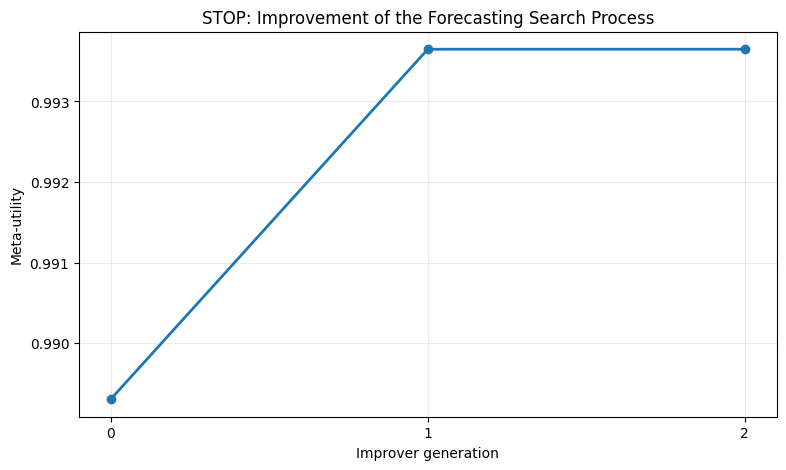

In [ ]:
# ==============================================================================
# 27. OUTER-LOOP VISUALIZATION
# ==============================================================================

print("=" * 88)
print("STOP HISTORY")
print("=" * 88)
print(
    STOP_HISTORY.to_string(
        index=False
    )
)
print()

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    STOP_HISTORY["generation"],
    STOP_HISTORY["meta_utility"],
    marker="o",
    linewidth=2,
)

plt.xticks(
    STOP_HISTORY["generation"]
)

plt.xlabel(
    "Improver generation"
)

plt.ylabel(
    "Meta-utility"
)

plt.title(
    "STOP: Improvement of the Forecasting Search Process"
)

plt.grid(
    alpha=0.25
)

plt.show()




## Cell 28 — Inner-loop visualization

The inner-loop chart examines the process behind each outer-loop point. For every improver specification, this cell constructs an improver, runs its policy search on the training markets, and collects the best score after each round. It then plots a separate trajectory for each generation's recipe. The horizontal axis now counts policy-improvement rounds, not outer generations or market dates.

All trajectories begin from the same initial policy. That common starting point aids comparison. A steep initial improvement indicates rapid discovery of a stronger policy. A later increase indicates that additional rounds discovered something useful beyond the early candidates. A flat path indicates that the retained policies did not improve under the measured objective during those rounds.

Because existing population members remain eligible, a trajectory's best validation score should not fall within a successfully completed run with fixed evaluation inputs. That behavior results from the selection mechanism, not from an assumption that every generated candidate is better. Most proposals may be unhelpful while the strongest incumbent simply survives. The chart summarizes the best retained result, so it does not show the distribution of rejected candidate quality.

This cell reconstructs histories by rerunning improvers; run_stop did not retain those histories. Identical prompts generally reuse the response cache. If the entries are unavailable, the rerun may request new responses, consume allowance, and produce a different search path. Treat the chart as a reconstructed trajectory under the session's state, rather than an stored audit of every original inner evaluation.

Longer lines are not automatically better procedures. They may represent more search work without a gain. A future comparison could plot improvement against calls, tokens, or elapsed time. For this pedagogical version, the lesson is nesting: an outer generation specifies a method, and this chart reveals the rounds through which that method searches for forecasting policies.


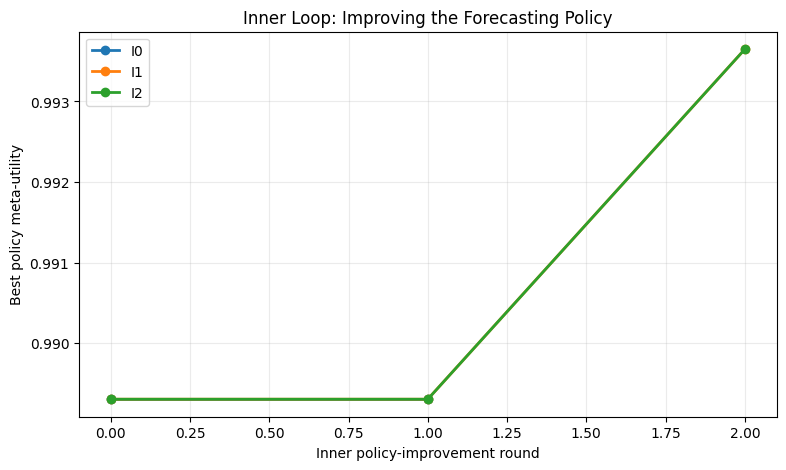

In [ ]:
# ==============================================================================
# 28. INNER-LOOP VISUALIZATION
# ==============================================================================

inner_rows = []

for generation, spec in enumerate(
    IMPROVER_SPECS
):

    improver = ForecastImprover(
        name=f"I{generation}",
        spec=spec,
    )

    _, _, history = improver.improve(
        TRAIN_MARKETS
    )

    for row in history:

        inner_rows.append(
            {
                "improver": f"I{generation}",
                "round": row["round"],
                "best_meta_utility": row[
                    "best_meta_utility"
                ],
            }
        )

INNER_HISTORY = pd.DataFrame(
    inner_rows
)

plt.figure(
    figsize=(9, 5)
)

for name in INNER_HISTORY[
    "improver"
].unique():

    subset = INNER_HISTORY[
        INNER_HISTORY["improver"]
        == name
    ]

    plt.plot(
        subset["round"],
        subset["best_meta_utility"],
        marker="o",
        linewidth=2,
        label=name,
    )

plt.xlabel(
    "Inner policy-improvement round"
)

plt.ylabel(
    "Best policy meta-utility"
)

plt.title(
    "Inner Loop: Improving the Forecasting Policy"
)

plt.legend()
plt.grid(alpha=0.25)
plt.show()




## Cell 29 — Held-out transfer test

The held-out evaluation tests selected policies on different synthetic histories. For each generation's selected policy, the cell evaluates the test period of every held-out market. It records utility, RMSE, and directional accuracy, then groups the results by generation to produce an average summary and a bar chart of held-out utility.

This boundary matters. These market seeds were not used to construct the base-model scorecard or select candidate policies and improver specifications. They are realizations of the same synthetic generating mechanism. This provides a more demanding check than reevaluating the training-market validation periods, while remaining within the laboratory's chosen family of environments. It does not establish transfer to real markets or different data-generating processes.

Identify what transfers here. The cell applies selected forecasting policies to held-out markets. It does not run each evolved improver on a new policy-search task in those markets. Therefore, it tests policy transfer, not directly the general-framework claim that an improved improver learns a reusable search method across new tasks. Testing that stronger claim would require an additional experimental design.

The base forecasting models still follow their permitted walk-forward fitting schedule within each held-out history. A held-out market is unseen by policy selection, but the forecasting tools can learn from its past observations as time advances. This is compatible with evaluating a forecasting rule prospectively: the rule may update its estimators using information available before each prediction without exposing future outcomes to the selection process.

Compare held-out utility with one, the naive benchmark, and compare generations without assuming their ranking must match validation. A later recipe's selected policy can generalize worse despite better development results. If these test results are repeatedly used to redesign the system, they become development feedback. Preserve an untouched assessment set before making stronger claims in an extended research application or strategy study.


HELD-OUT TRANSFER RESULTS
improver  mean_utility  mean_rmse  mean_directional_accuracy
      I0      0.996561   0.011563                   0.548485
      I1      0.981650   0.011757                   0.478788
      I2      0.981650   0.011757                   0.478788



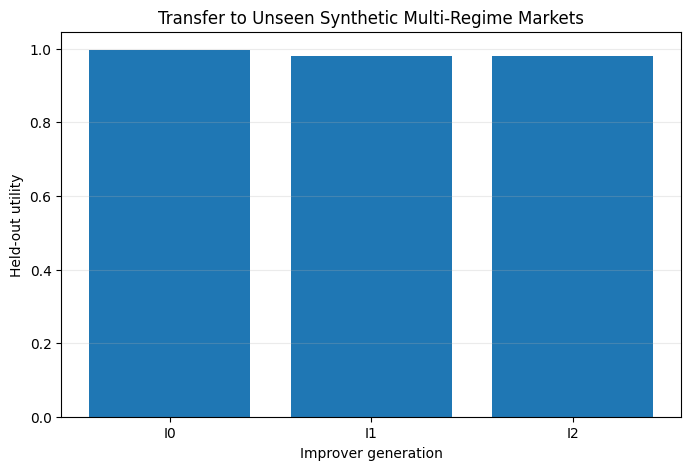

In [ ]:
# ==============================================================================
# 29. HELD-OUT TRANSFER TEST
# ==============================================================================

transfer_rows = []

for generation, policy in enumerate(
    EVOLVED_POLICIES
):

    for market in TEST_MARKETS:

        metrics = evaluate_policy(
            market=market,
            policy=policy,
            split="test",
        )

        transfer_rows.append(
            {
                "improver": f"I{generation}",
                "market": market.name,
                **metrics,
            }
        )

TRANSFER_RESULTS = pd.DataFrame(
    transfer_rows
)

TRANSFER_SUMMARY = (
    TRANSFER_RESULTS
    .groupby("improver")
    .agg(
        mean_utility=("utility", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_directional_accuracy=(
            "directional_accuracy",
            "mean",
        ),
    )
    .reset_index()
)

print("=" * 88)
print("HELD-OUT TRANSFER RESULTS")
print("=" * 88)
print(
    TRANSFER_SUMMARY.to_string(
        index=False
    )
)
print()

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    TRANSFER_SUMMARY["improver"],
    TRANSFER_SUMMARY["mean_utility"],
)

plt.xlabel(
    "Improver generation"
)

plt.ylabel(
    "Held-out utility"
)

plt.title(
    "Transfer to Unseen Synthetic Multi-Regime Markets"
)

plt.grid(
    axis="y",
    alpha=0.25,
)

plt.show()




## Cell 30 — Price forecast demonstration

This demonstration translates the final policy's return forecasts into index levels. FINAL_POLICY is taken from the last recorded improver generation, and the first held-out market becomes the example. The cell obtains daily ensemble return forecasts, combines each with that day's observed index level, and plots the corresponding next-day price prediction against the realized next-day index level.

The exponential conversion follows the generator's use of log returns. A predicted log return is exponentiated and multiplied by the current price to obtain a predicted next price. This is a transformation of the return forecast, not a separate model trained on prices. This convention differs from the simple-return formula, where the predicted percentage change would instead be added to one.

Each plotted prediction is anchored to the observed price on its forecast date. The figure is therefore a sequence of one-step forecasts, not a single recursively projected future price path. It does not feed yesterday's predicted price into today's calculation. The date labels refer to the feature rows used to forecast the following observation, an indexing convention worth remembering when reading the visual alignment.

Price curves can look close even when forecasts add little value. A naive zero-return forecast simply predicts tomorrow's price equals today's, and adjacent daily prices often differ modestly relative to the index level. For that reason, visual similarity alone cannot establish forecasting skill. The return-error utility and benchmark comparison from earlier cells provide the more relevant evidence about incremental predictive performance.

The demonstration also does not show a trading account. No position is entered, no execution price is modeled, and no profit or loss is accumulated. Its purpose is communication: it helps students connect an abstract array of return predictions to a market chart. The next diagnostic examines errors to identify hidden conditions associated with stronger or weaker performance.


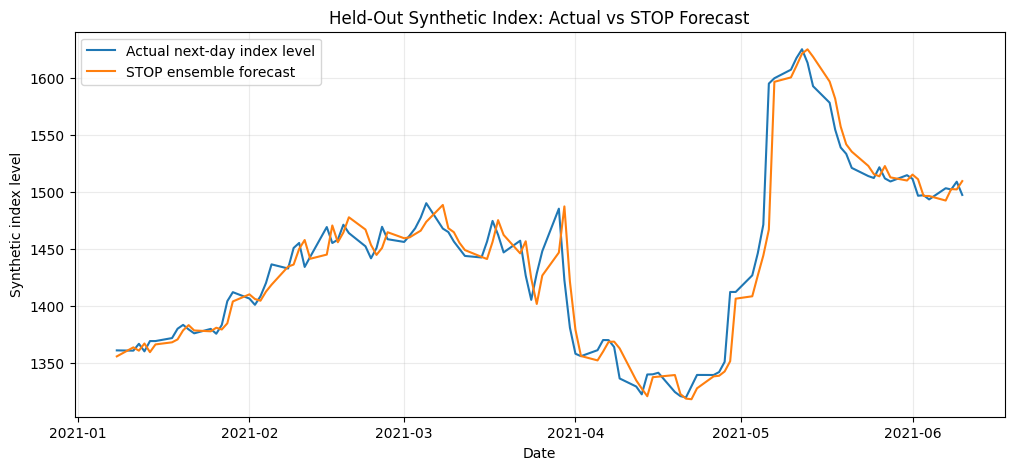

In [ ]:
# ==============================================================================
# 30. PRICE FORECAST DEMONSTRATION
# ==============================================================================

FINAL_POLICY = EVOLVED_POLICIES[-1]

DEMO_MARKET = TEST_MARKETS[0]

demo_predictions = (
    DEMO_MARKET
    .test_predictions
    .copy()
)

demo_return_forecast = predict_with_policy(
    market=DEMO_MARKET,
    predictions=demo_predictions,
    policy=FINAL_POLICY,
)

demo_predictions[
    "forecast_return"
] = demo_return_forecast

demo_predictions[
    "forecast_price"
] = (
    demo_predictions["current_price"]
    * np.exp(
        demo_predictions["forecast_return"]
    )
)

display_window = demo_predictions.tail(
    120
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    display_window["date"],
    display_window["actual_price"],
    label="Actual next-day index level",
)

plt.plot(
    display_window["date"],
    display_window["forecast_price"],
    label="STOP ensemble forecast",
)

plt.xlabel("Date")
plt.ylabel("Synthetic index level")
plt.title(
    "Held-Out Synthetic Index: Actual vs STOP Forecast"
)
plt.legend()
plt.grid(alpha=0.25)
plt.show()




## Cell 31 — Regime-diagnostic performance

The regime diagnostic uses information that the forecasting policy was deliberately denied: the generator's true regime labels. It evaluates the final policy on each held-out market's test period, attaches its forecasts to the prediction table, and groups observations by recorded hidden regime. This investigates differences during calm trends, volatile declines, sideways periods, or recoveries.

Using hidden labels now creates no contradiction. The policy made its decisions through the observable proxy, while this cell uses the generator's labels afterward to understand the results. A teacher similarly knows the answer when grading without providing that answer to students beforehand. Diagnostic information is appropriate when it remains outside the decision rule being evaluated.

For each market-regime subset with at least five observations, the code reports utility, RMSE, directional accuracy, and observation count. The final display averages these metrics across market-level subsets. It does not pool all observations into one regime-wide error calculation, and it does not weight the displayed averages by each subset's size. Small and large qualifying subsets can therefore influence the displayed mean equally.

The stored label belongs to the current feature row, while the forecast target is the next return. Around regime transitions, the target can be generated under a different next-day state. The diagnostic therefore describes performance conditional on the recorded current regime, rather than labeling the mechanism governing every target return. This timing detail matters when interpreting behavior around changes in market conditions.

Use the results to ask focused questions. Is weakness concentrated in one condition? Does the observable proxy confuse conditions that require different ensembles? Are there too few observations for a stable interpretation? These questions identify possible future research directions, but this cell does not revise the policy. Changing the model after inspecting these held-out diagnostics would make them part of development feedback for a experiment.


In [ ]:
# ==============================================================================
# 31. REGIME-DIAGNOSTIC PERFORMANCE
# ==============================================================================

regime_rows = []

for market in TEST_MARKETS:

    predictions = (
        market.test_predictions.copy()
    )

    policy_pred = predict_with_policy(
        market,
        predictions,
        FINAL_POLICY,
    )

    predictions[
        "policy_prediction"
    ] = policy_pred

    for regime_id, regime_name in (
        REGIME_NAMES.items()
    ):

        subset = predictions[
            predictions["true_regime"]
            == regime_id
        ]

        if len(subset) < 5:
            continue

        actual = subset[
            "actual_return"
        ].values

        candidate = subset[
            "policy_prediction"
        ].values

        naive = subset[
            "m01"
        ].values

        regime_rows.append(
            {
                "market": market.name,
                "true_regime": regime_name,
                "observations": len(subset),
                "utility": prediction_utility(
                    actual,
                    candidate,
                    naive,
                ),
                "rmse": rmse(
                    actual,
                    candidate,
                ),
                "directional_accuracy": directional_accuracy(
                    actual,
                    candidate,
                ),
            }
        )

REGIME_RESULTS = pd.DataFrame(
    regime_rows
)

print("=" * 88)
print("FINAL POLICY PERFORMANCE BY TRUE HIDDEN REGIME")
print("=" * 88)

print(
    REGIME_RESULTS.groupby(
        "true_regime"
    )[
        [
            "utility",
            "rmse",
            "directional_accuracy",
        ]
    ]
    .mean()
    .to_string()
)

print()




FINAL POLICY PERFORMANCE BY TRUE HIDDEN REGIME
                          utility      rmse  directional_accuracy
true_regime                                                      
bear_high_vol            0.967607  0.020082              0.292921
bull_low_vol             0.989597  0.006504              0.513353
recovery_momentum        1.009969  0.010293              0.515152
sideways_mean_reverting  0.998218  0.009890              0.491228



## Cell 32 — Inspect final policy

Final-policy inspection makes the search result readable. Earlier charts summarize scores, but they do not reveal which models were selected or how their forecasts were combined. This cell converts FINAL_POLICY into a dictionary and prints formatted JSON. The output contains the global fallback and the four observable-regime blocks, each with model identifiers and normalized forecast weights.

Read identifiers alongside the menu. A number references an implementation, not a new algorithm invented by the language model. Comparing blocks reveals whether the search discovered conditional specialization or repeated the same ensemble across conditions. A policy with identical blocks may still forecast differently each day because its model predictions change with the information.

The weights express influence on an ensemble forecast. They are not asset allocation percentages, leverage choices, or probabilities that a model is correct. If a model receives half the weight in the high-volatility block, it contributes half of that block's weighted forecast under the current normalization. Translating forecast influence into trading exposure would require a separate decision layer that this notebook does not implement.

Compare the result with INITIAL_POLICY to see what changed. Did the search simplify the ensemble, replace a model family, or concentrate weight on a conservative forecast? Such observations help formulate explanations, but they should remain hypotheses about why performance changed. The printed policy alone does not provide causal evidence that a modification was responsible for an improvement in utility.

FINAL_POLICY means the policy associated with the last recorded generation. It is not chosen here by retrospectively selecting the best held-out score. Preserving that convention helps keep the test from becoming another selection mechanism. This cell demonstrates a useful governance property of bounded specifications: the resulting decision rule remains inspectable, serializable, and comparable even though a language model participated in discovering it through a nested search process.


In [ ]:
# ==============================================================================
# 32. INSPECT FINAL POLICY
# ==============================================================================

print("=" * 88)
print("FINAL EVOLVED FORECASTING POLICY")
print("=" * 88)

print(
    json.dumps(
        policy_to_dict(
            FINAL_POLICY
        ),
        indent=2,
    )
)

print()




FINAL EVOLVED FORECASTING POLICY
{
  "global": {
    "model_ids": [
      1,
      8,
      13,
      16
    ],
    "weights": [
      0.3,
      0.25,
      0.25,
      0.2
    ]
  },
  "positive_trend": {
    "model_ids": [
      9,
      6,
      16,
      19
    ],
    "weights": [
      0.3,
      0.25,
      0.25,
      0.2
    ]
  },
  "negative_trend": {
    "model_ids": [
      13,
      5,
      16,
      4
    ],
    "weights": [
      0.3,
      0.25,
      0.25,
      0.2
    ]
  },
  "high_vol": {
    "model_ids": [
      1,
      13,
      4,
      2
    ],
    "weights": [
      0.35,
      0.25,
      0.2,
      0.2
    ]
  },
  "sideways": {
    "model_ids": [
      4,
      2,
      5,
      11
    ],
    "weights": [
      0.3,
      0.25,
      0.25,
      0.2
    ]
  }
}



## Cell 33 — Audit / resource summary

The audit summary describes proposal-generation resource use. It prints the configured language model, the successful-call counter, the number of cached responses, and the number of recorded outer selection events. When selection events exist, it displays their contents. This connects results to procedural changes rather than leaving optimization invisible.

Two kinds of memory support this notebook. Numerical forecast files remember expensive deterministic calculations. The response_cache dictionary remembers language model answers for identical request keys in the current session. This cell reports the latter, not the total number or size of cached forecast files. Distinguishing the caches helps explain why a rerun may avoid model fitting yet still need new proposal requests after session memory is reset.

The successful-call counter is useful but incomplete. It increments after a response has been received and processed by the wrapper. Failed attempts, possible service-client retries, token counts, monetary charges, and elapsed search time are not summarized here. The reported ceiling should therefore be interpreted as the notebook's implemented call-control mechanism, not as a accounting or guarantee of total resource consumption.

The audit log records proposal-call metadata and outer winners, but this display filters specifically for meta_selection events. It does not show every rejected policy, every candidate's detailed forecasts, or every inner decision. Those limitations define the current teaching implementation. A more extensive system could preserve full candidate lineage and resource measurements so that comparisons between search procedures include their operational costs as well as their scores.

This returns us to the general framework's emphasis on the surrounding scaffold. Memory, accounting, and traceability affect whether improvement can be reproduced and understood. A high score without a record of the procedure is harder to interpret. Use this summary to connect observed performance with the actual sequence of accepted search configurations and the limited resource evidence retained here.


In [ ]:
# ==============================================================================
# 33. AUDIT / RESOURCE SUMMARY
# ==============================================================================

print("=" * 88)
print("AUDIT / RESOURCE SUMMARY")
print("=" * 88)

print(
    "Claude model:",
    MODEL
)

print(
    "API calls used:",
    api_calls,
    "/",
    MAX_API_CALLS,
)

print(
    "Cached Claude responses:",
    len(
        response_cache
    )
)

meta_events = [
    event
    for event in audit_log
    if event.get("kind")
    == "meta_selection"
]

print(
    "Outer meta-selection events:",
    len(meta_events)
)

print()

if meta_events:
    print(
        pd.DataFrame(
            meta_events
        ).to_string(
            index=False
        )
    )

print()




AUDIT / RESOURCE SUMMARY
Claude model: claude-sonnet-5
API calls used: 14 / 50
Cached Claude responses: 14
Outer meta-selection events: 2

          kind  generation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      winner  meta_utility
meta_selection           1 {'candidates_per_round': 4, 'rounds': 2, 'keep_top_k': 2, 'search_style': 'Explore-then-exploit: in round 1 generate broad, family-diverse candidates spanning statistical, econometric, and ML models to map the performance landscape; in round 2 refine only the top performers by recombining their strongest sub-compone

## Cell 34 — Architecture map

The architecture map closes the executable part of the notebook by pairing STOP concepts with their concrete implementations. It is a conceptual inventory, not another optimization. Its rows connect the teaching note to code: synthetic environments, forecasting policies, utility functions, improver specifications, nested searches, transfer evaluation, and supporting controls.

Start with the downstream task. The environment is a synthetic market, the available tools are twenty forecasting models, and the candidate solution is a regime-dependent ensemble policy. The evaluator compares forecast error with a naive benchmark. Those components describe what the inner loop searches over and how a proposed solution earns a score. They correspond to the basic generate, evaluate, and select structure introduced in the general framework.

Next, locate the second optimization level. A seed improver specifies how policy search proceeds. Candidate improver specifications change proposal breadth, search depth, survivor count, and strategic instructions. Their quality is measured through the policies they discover. Repeating that selection creates the I0 to I1 to I2 sequence. The mapping therefore explains how a search procedure becomes an object of optimization without suggesting that model weights are changing.

Read two rows with the qualifications established earlier. The transfer row refers operationally to selected policies applied to unseen synthetic histories, rather than a fresh evaluation of improvers on new search tasks. The governance row identifies implemented mechanisms such as secrets, counters, caches, and audit entries; it does not imply that this teaching notebook already provides a complete institutional governance or deployment system.

The final message marks workflow completion. Before drawing conclusions, reconstruct the causal chain yourself: a specification organizes proposals, proposals become policies, policies combine forecasts, and numerical outcomes determine selection. These relationships can survive a change of application. Replacing forecasting candidates with trading strategies changes the tools and evaluator while preserving that organizing principle.


In [ ]:
# ==============================================================================
# 34. ARCHITECTURE MAP
# ==============================================================================

architecture = pd.DataFrame(
    [
        [
            "Synthetic environment",
            "Multi-regime stock-index generator",
        ],
        [
            "Initial candidate menu",
            "20 statistical/econometric/ML forecasting models",
        ],
        [
            "Downstream object",
            "Regime-adaptive model-selection / ensemble policy",
        ],
        [
            "Downstream utility",
            "Forecast RMSE relative to naive zero-return benchmark",
        ],
        [
            "Inner loop",
            "Search for better regime-specific ensembles",
        ],
        [
            "Seed improver I0",
            "SEED_IMPROVER_SPEC",
        ],
        [
            "Meta-utility",
            "Average policy utility across synthetic training markets",
        ],
        [
            "Outer loop",
            "Improve candidates_per_round, rounds, keep_top_k, search_style",
        ],
        [
            "STOP recursion",
            "I0 -> I1 -> I2",
        ],
        [
            "Transfer",
            "Held-out synthetic markets and unseen regime sequences",
        ],
        [
            "Governance",
            "Colab Secret + API budget + cache + audit trail",
        ],
    ],
    columns=[
        "STOP concept",
        "Implementation",
    ],
)

print("=" * 88)
print("ARCHITECTURE MAP")
print("=" * 88)

print(
    architecture.to_string(
        index=False
    )
)

print()
print("Experiment complete.")


ARCHITECTURE MAP
          STOP concept                                                 Implementation
 Synthetic environment                             Multi-regime stock-index generator
Initial candidate menu               20 statistical/econometric/ML forecasting models
     Downstream object              Regime-adaptive model-selection / ensemble policy
    Downstream utility          Forecast RMSE relative to naive zero-return benchmark
            Inner loop                    Search for better regime-specific ensembles
      Seed improver I0                                             SEED_IMPROVER_SPEC
          Meta-utility       Average policy utility across synthetic training markets
            Outer loop Improve candidates_per_round, rounds, keep_top_k, search_style
        STOP recursion                                                 I0 -> I1 -> I2
              Transfer         Held-out synthetic markets and unseen regime sequences
            Governance               

## Conclusion — From forecasting models to algorithmic trading strategies

This notebook has translated the general STOP framework into a concrete forecasting experiment. We began with a fixed collection of models and a simple ensemble policy. The inner loop searched for better policies, while the outer loop compared different procedures for conducting that search. The achievement is architectural: the method used to find a solution became an object of evaluation and improvement. A fixed language model supplied proposals at both levels, while deterministic calculations determined which proposals survived under the specified objective.

Our implementation made that architecture bounded and inspectable. Policies were represented as model identifiers and weights, and improvers were represented by four configurable fields. The Python control flow, forecasting menu, feature definitions, regime proxy, and scoring rule remained fixed. Consequently, this is a pedagogical application of scaffold improvement rather than a full reproduction of recursive code rewriting. That choice preserves the essential distinction between improving a solution and improving the procedure that searches for solutions, while making the experiment practical to run and explain.

Computational design contributed to that practicality. Scheduled model refits reduced repeated estimation, daily features continued to produce daily predictions, and cached forecast matrices supported repeated policy comparisons. These choices separated expensive numerical preparation from the search over combinations. The refit schedule changes the forecasting protocol, whereas caching reuses calculations from an unchanged protocol. Neither mechanism is itself evidence of recursive intelligence. Together, they demonstrate that effective agentic systems depend on careful engineering of tools, memory, evaluation, and orchestration around the language model.

The results must be interpreted within the experiment's boundaries. Utility measures forecasting error relative to a naive benchmark, not trading profitability. Validation performance guides both levels of search and can become overfitted through repeated selection. The held-out evaluation examines selected policies on new histories from the same synthetic generator; it does not directly establish that an evolved improver transfers to entirely new search problems. These distinctions strengthen the lesson because they identify what was implemented, what was measured, and which broader claims would require further evidence.

An application can replace the forecasting menu with a menu of complete algorithmic trading strategies. Candidates might combine momentum, mean reversion, relative-value, or defensive approaches, each with explicit signal generation, position sizing, rebalancing, and execution assumptions. The inner loop would search over strategy selection and combination. The outer loop would improve how that search explores alternatives, preserves promising designs, allocates experiments, and stops. Evaluation would need to incorporate costs, slippage, turnover, drawdowns, exposure constraints, and performance across separated development and assessment periods, rather than relying solely on forecast accuracy.

The principle remains the same: define the permissible candidates, evaluate them consistently, select using evidence, and improve the procedure through its downstream results. More complex strategies enlarge the decision space; they do not remove the need for a clear objective and tests. STOP therefore offers a disciplined way to study adaptive trading research systems whose search methods can evolve while their evaluation boundaries remain explicit, inspectable, and open to independent challenge before any deployment decision is considered.


### A Narrative for furhter considerations

The central idea of this notebook is that an intelligent system can improve both its answers and the procedure it uses to discover those answers. In our application, the immediate problem is forecasting the next return of a synthetic stock index. However, the deeper learning objective is understanding how improvement can operate at two connected levels. The inner loop searches for better combinations of forecasting models. The outer loop searches for better ways to conduct that search. Together, these nested loops provide a practical, bounded implementation of the STOP framework, making an abstract idea visible through experiments that we can inspect.

Everything begins with a collection of twenty forecasting models. Each model offers a different perspective on the same market, and its predictions are computed before the search begins. This separation matters because evaluating a new combination does not require repeatedly rebuilding every underlying model. The system can reuse cached forecasts and concentrate its effort on discovering useful combinations. A forecasting policy specifies which models to include and how much weight to assign to each. These choices can differ across observable market conditions, including positive trends, negative trends, high volatility, and sideways behavior. The result is a regime-adaptive ensemble.

The inner loop already includes an LLM in this implementation. Its role is to propose alternative forecasting policies using the model menu, the current policy, a validation scorecard, and search instructions. Its response is structured JSON containing model identifiers and weights. Python interprets that response, checks the configuration, normalizes the weights, and constructs the corresponding forecasts. This division of responsibilities is fundamental: the language model generates proposals, while executable procedures determine how those proposals perform. The LLM does not establish quality by describing a combination persuasively. Each proposed combination must demonstrate its usefulness against observed outcomes in the validation data.

Utility provides the common language for comparing those proposals. Here, utility measures forecasting accuracy relative to a baseline that predicts zero return. The program divides the baseline’s root mean squared error by the candidate policy’s error and caps the resulting score at 1.5. A value above one means the candidate beats the baseline; a value below one means it performs worse. The policy’s selection score averages utility across training markets using their validation observations. The inner loop ranks new candidates alongside surviving parents and retains the best policies. Repetition allows the search to build on combinations that have already performed well.

The outer loop asks a different question: what search procedure is most effective at finding strong policies? Instead of proposing model weights, the LLM proposes improver specifications. These determine how many candidates to generate, how many search rounds to run, how many policies to retain, and what strategic instructions should guide exploration. Python then runs the inner loop for each specification, starting from the same initial policy. Each improver receives the score of the best policy it discovers. The winning specification becomes the parent for another generation. This is improvement of a configurable search process, without rewriting the underlying program.

Understanding the limits of this implementation helps us see how it could evolve. The LLM remains fixed, the forecasting models remain fixed during policy search, and the available configuration fields define the boundaries of adaptation. Moreover, selecting the highest validation score does not establish that a policy will generalize. Repeated search can exploit peculiarities of the validation samples. Held-out evaluation therefore serves a separate purpose: examining transfer after selection. Future versions could use multiple chronological validation windows, additional synthetic environments, and explicit computational budgets. Search cost could also enter the objective numerically, rather than appearing only as an instruction.

A richer inner loop would expand the LLM’s existing role from proposing combinations to interpreting evidence. After evaluating candidates, the system could provide a structured report showing performance by regime, persistent errors, model redundancy, and sensitivity to changing conditions. The LLM could then propose a specific explanation and a targeted experiment. For example, it might investigate whether several models fail together because they share similar assumptions. Python would test that hypothesis through controlled comparisons. This would create a more informative cycle of proposal, measurement, diagnosis, and revision. Explanations would guide experiments, while measured results would continue to determine acceptance.

The next conceptual step is replacing forecasting models with complete algorithmic trading strategies. A strategy contains more than a prediction: it specifies when to enter, when to exit, how much capital to allocate, and how to manage exposure. Candidate strategies could include trend following, statistical arbitrage, volatility targeting, or combinations of these approaches. The inner loop would search over strategy configurations or portfolios of strategies. Utility would consequently need redesign. Forecast accuracy alone would be insufficient. Evaluation could incorporate net returns, drawdowns, transaction costs, turnover, liquidity constraints, and risk limits, with explicit rules governing trade-offs and unacceptable outcomes.

Strategies could also be represented by LLM-based agents. An agent might interpret research, assess market conditions, and propose actions within a defined mandate. However, this representation would need an operational contract: permitted inputs, available tools, decision frequency, output format, and enforceable limits. Otherwise, comparisons between strategies would become difficult to reproduce. One agent could specialize in macroeconomic interpretation, another in market microstructure, and another in evaluating competing signals. Their proposals would pass through deterministic portfolio and execution controls. Historical evaluation would also need safeguards against information leakage, including the possibility that a language model already knows later historical events.

More sophisticated versions could introduce agents responsible for research, experimentation, risk review, execution, and monitoring. A coordinating agent could allocate work, request evidence, and decide which hypotheses deserve testing. The outer loop might eventually compare these organizational arrangements, asking which combination of roles and communication rules produces better decisions under a common budget. Changes would require controlled evaluation before deployment, with records and rollback mechanisms. The enduring principle remains straightforward: propose alternatives, measure outcomes, preserve useful improvements, and improve the process itself. Sophistication comes from making this learning cycle more capable, more accountable, and more relevant to actual trading decisions.